# Task 3 — Gender and Usage Classification

**Status:** development comparisons and the final Gender SAM25 and Usage E8 refits are complete. Final assessment is recorded in [04_task3_final_evaluation.ipynb](04_task3_final_evaluation.ipynb).

**Replay:** **Run All** reads the saved records and rebuilds the analysis below. It does not start training or new inference.

**Training code map:** the companion notebooks launch training; the Python files below implement it.

| Layer | Exact implementation | Responsibility |
|---|---|---|
| Experiment declarations | [config.py](../src/fashion/train/config.py): `Task3BaselineConfig`; [task3_experiments.py](../src/fashion/train/task3_experiments.py); target-specific modules in [src/fashion/train/](../src/fashion/train/) | Define the baseline and each child recipe, including folds, loss, augmentation and epoch budget. |
| Neural model definitions | [model.py](../src/fashion/train/model.py): `Task3BaselineCNN`, `Task3GeM3CNN` and alternative architectures | Build the scratch CNNs. The final Usage model uses average pooling; the final Gender model uses GeM pooling. |
| Run entry points | [task3_training/README.md](task3_training/README.md); [baseline runner](task3_training/smallcnn_baseline_training.ipynb); [child runner](task3_training/smallcnn_child_experiments.ipynb) | Map the original experiment notebooks and their local or Colab runtime. Each runner sets up data, calls its training module and saves outputs. |
| Baseline and child orchestration | [task3_baseline.py](../src/fashion/train/task3_baseline.py): `run_task3_baseline_cv`, `run_task3_baseline_fold`; [task3_experiments.py](../src/fashion/train/task3_experiments.py): `run_task3_child_cv` | Fit the declared recipes on the saved development folds and record fold predictions and metrics. |
| Gender follow-up orchestration | [MixUp](../src/fashion/train/task3_gender_mixup.py): `run_gender_mixup_screen`; [SAM25 screen](../src/fashion/train/task3_gender_sam25.py): `run_gender_sam25_screen`; [five-fold confirmation](../src/fashion/train/task3_gender_sam25_cv.py): `run_gender_sam25_cv` | Test regularisation on the corrected-label basis, then confirm the fixed SAM25 recipe on all five development folds. |
| Usage expansion orchestration | [120 additions](../src/fashion/train/task3_usage_expanded.py): `run_expanded_usage`; [687 additions](../src/fashion/train/task3_usage_expanded_v2.py): `run_expanded_usage_v2`; [MixUp + SAM](../src/fashion/train/task3_usage_mixup_sam.py): `run_usage_mixup_sam`; [replacement follow-up](../src/fashion/train/task3_usage_replaced_v3.py) | Select each approved dataset version explicitly and compare predictions on the retained teacher folds. |
| Optimisation and input processing | [task3_baseline.py](../src/fashion/train/task3_baseline.py); [mixup.py](../src/fashion/train/mixup.py); [sam.py](../src/fashion/train/sam.py); [images.py](../src/fashion/data/images.py) | Run the fold training loop, apply the requested MixUp/SAM policy, and use the shared image transform. Full-development refits have their own loops in the modules below. |
| Full-development refits | [Gender runner](task3_training/gender_sam25_refit.ipynb) → [task3_gender_sam25_refit.py](../src/fashion/train/task3_gender_sam25_refit.py): `run_gender_sam25_refit`; [Usage E1 runner](task3_training/usage_e1_refit.ipynb) → [task3_usage_e1_refit.py](../src/fashion/train/task3_usage_e1_refit.py): `run_usage_e1_refit`; [Usage E8 runner](task3_training/usage_e8_refit.ipynb) → [task3_usage_e8_refit.py](../src/fashion/train/task3_usage_e8_refit.py): `run_usage_e8_refit` | Train fresh weights after fixing the recipes: 25 epochs for Gender and 30 for Usage, with no validation-based checkpoint selection. E1 is the Usage comparison; E8 is the accepted model. |
| Saved training outputs | [registry.py](../src/fashion/train/registry.py); [runs.csv](../results/runs.csv); [training evidence](../results/evidence/task3/); [Gender package](../results/task3/gender_model/); [Usage package](../results/task3/usage_model/) | Preserve run records, histories, checkpoints, settings and class order. Each model package includes its loading README. |

**Training flow:** experiment settings → companion training notebook → target-specific runner → training loop → registry, checkpoint and evidence → analysis in this notebook.

**A. Replay the completed analysis:** open `notebooks/04_task3_gender_usage.ipynb`, select the repository `.venv` kernel, then choose **Restart Kernel and Run All Cells**.

**B. Run a training experiment:** open its notebook from [the runner index](task3_training/README.md). For Colab runners, select the stated GPU, check `BRANCH`, and run the setup and training cells in order. Setup fetches code from GitHub and reuses the saved ZIPs in `MyDrive/MLA2/data/`. Local runners use the repository `.venv` kernel. Keep the runner's named parent runs, saved folds, class map and output folder.

**C. Follow the final-model call chains:**

- Gender development: [gender_sam25_five_fold.ipynb](task3_training/gender_sam25_five_fold.ipynb) → `task3_gender_sam25_cv.run_gender_sam25_cv` → `task3_baseline.run_task3_baseline_fold`.
- Gender final refit: [gender_sam25_refit.ipynb](task3_training/gender_sam25_refit.ipynb) → `task3_gender_sam25_refit.run_gender_sam25_refit` → [original final_epoch.pt](../results/evidence/task3/gender_sam25_refit_20260907/final_epoch.pt) → [packaged final_epoch.pt](../results/task3/gender_model/final_epoch.pt).
- Usage final refit: [usage_e8_refit.ipynb](task3_training/usage_e8_refit.ipynb) → `task3_usage_e8_refit.run_usage_e8_refit` → [original final_epoch.pt](../results/evidence/task3/usage_e8_refit_20260907/final_epoch.pt) → [packaged final_epoch.pt](../results/task3/usage_model/final_epoch.pt).


### Development study

The development study began with two targets drawn from the same product images, but their
errors led to different lines of investigation. Gender required stronger image features,
careful label review and reduced memorisation. Usage required attention to rare classes;
improved weighting and position tolerance still left failures that additional retail images
did not resolve. This notebook follows those decisions through the saved experiments,
including the alternatives that failed and the costs of the retained changes.

The account starts with the shared data audit and baseline. It then traces Gender from
pooling to the fixed SAM25 recipe, followed by Usage from class weighting to data expansion
and the teacher-only E8 refit. Each comparison retains its own folds, labels and evaluation
population so that changes in the evidence remain distinct from changes in the model.

**Run All** rebuilds the analysis from saved development and training records, without training
or new inference. Reserved-holdout results and final judgements are reported in the Task 3
evaluation notebook (`04_task3_final_evaluation.ipynb`). The teacher test set is prediction-only;
no test scores are reported here. The selected recipes, training curves and saved preprocessing
are shown below.


## 1. Runtime setup

The comparison rests on a fixed collection of saved evidence. The local environment and
file checks below establish that the tables and figures refer to that same collection.


### Find the project and select its environment

In [1]:
import os
import sys
from pathlib import Path

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
REPO_DIR = next(path for path in candidates if (path/'src/fashion').is_dir())
assert Path(sys.prefix).resolve() == (REPO_DIR/'.venv').resolve(), 'Select the project .venv kernel'
os.chdir(REPO_DIR)
os.environ["FASHION_PROJECT_ROOT"] = str(REPO_DIR)
sys.path.insert(0, str(REPO_DIR / "src"))
TASK3_EVIDENCE_ROOT = REPO_DIR/'results/evidence/task3'
PACK = REPO_DIR/'reports/task3/main_report_20260906'
USAGE_HISTORY = REPO_DIR/'reports/task3/usage_final_e1_20260907'
USAGE_FINAL = REPO_DIR/'reports/task3/usage_final_e8_refit_20260907'
FIGURES = REPO_DIR/'results/figures/task3/main_analysis'
FIGURES.mkdir(parents=True, exist_ok=True)
print('Repository:', REPO_DIR)
print('Python:', sys.executable)

Repository: /home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda
Python: /home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda/.venv/bin/python


### Load libraries and verify saved files

In [2]:
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageEnhance, ImageOps

pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
evidence_lock = json.loads((PACK/'evidence_lock.json').read_text())
analysis_assets = json.loads((PACK/'analysis_assets.json').read_text())
for relative, expected in {**evidence_lock['files'], **analysis_assets}.items():
    saved = REPO_DIR / relative.replace('reports/task3_', 'reports/task3/', 1)
    assert hashlib.sha256(saved.read_bytes()).hexdigest() == expected, relative
registry = pd.read_csv(PACK/'results/runs.csv', keep_default_na=False).set_index('run_id',
    drop=False)
classical_registry = pd.read_csv(PACK/'results/classical_runs.csv',
    keep_default_na=False).set_index('run_id', drop=False)
registry = pd.concat([registry, classical_registry.loc[~classical_registry.index.isin(
    registry.index)]])
assert not registry.index.duplicated().any()
print(f'Checked {len(analysis_assets)} analysis sources and {len(registry)} saved run records.')

Checked 136 analysis sources and 156 saved run records.


## 2. Data and comparison rules

Before comparing learners, we fixed the data conditions under which a gain would be judged.
All candidates use the saved split, preventing an apparent improvement from coming from
an easier allocation of product families.


### Read the canonical data contract

In [3]:
splits = pd.read_csv(REPO_DIR / 'data/processed/splits.csv', keep_default_na=False)
development = splits.loc[splits.partition.eq('development')].copy()
development['cv_fold'] = development.cv_fold.astype(int)
gender_development = development.loc[development.has_gender_label.eq(True)].copy()
usage_development = development.loc[development.has_usage_label.eq(True)].copy()
label_maps = json.loads((REPO_DIR/'data/processed/label_maps.json').read_text())
assert len(development) == 32773 and development.cv_fold.nunique() == 5
assert development.groupby('product_family_group').cv_fold.nunique().max() == 1
display(splits.groupby('partition').size().rename('Images').to_frame())
print('Valid gender rows:', len(gender_development), '| valid usage rows:', len(usage_development))

,Images
partition,
development,32773
holdout,5778
quarantine,61


Valid gender rows: 32773 | valid usage rows: 32772


### Metrics and limits

Primary development metric for `gender`: pooled five-fold OOF macro-F1.
Primary development metric for `usage`: pooled five-fold OOF macro-F1.
OOF means each image is predicted by the model that did not train on its fold.
Macro-F1 gives each class equal weight. Accuracy counts all correct images equally.

All comparisons use `data/processed/splits.csv`, keep families together, and apply the target label-mask.
Two-fold screens use folds 0 and 4; they are development evidence, not fresh tests.
Tables pool confusion counts from registered runs; they do not average five F1 values.
The later audited IEEE tables are labelled separately because numeric precision can change a few predictions.
No plot joins scores across different label bases or fold sets.

Macro-F1 guides these development comparisons. Accuracy is reported alongside it so the cost
of treating rare classes equally stays visible. Final evaluation and its decision criteria belong in
the Task 3 evaluation notebook (`04_task3_final_evaluation.ipynb`).

These rules make the later comparison interpretable: a change in score is assessed only
after accounting for the rows, labels and folds on which it was measured.

Because cross-validation folds share training rows, their scores are not independent replicates [1].
We therefore report fold spread descriptively and use product-family resampling for paired comparisons.
Neither measure captures the full uncertainty from repeatedly choosing experiments on development data.


The dated `results/runs.csv` copy is the source for candidate comparison tables. Confusion counts are added before macro-F1 is computed; averaging fold scores gives a different number. Folds 0 and 4 are screens, not a full confirmation. Original and name-corrected labels stay visibly separate. Later matched IEEE audits check numeric precision and clean training gaps; they do not silently replace registry scores.

The label-mask excludes the one blank Usage target without dropping it from Gender. Literal `NA` remains a real Usage class. Separate models also avoid assuming that shared training helps both targets; negative transfer means a joint model helps one target while hurting the other. Only development evidence is analysed here. Fold validation is part of model development;
it is distinct from the reserved holdout used for final evaluation.

## 3. Shared EDA: inventory, decode, missing values and quarantine

The first source of uncertainty was the dataset itself. The shared preparation audit established
which rows had usable images and targets before any model comparison. The following evidence
reproduces the preparation steps shared with Notebook 01.


### Audit row identity, target masks and image geometry

In [4]:
issues = pd.read_csv(REPO_DIR / 'data/processed/audit/issues.csv', keep_default_na=False)
image_audit = pd.read_csv(REPO_DIR / 'data/processed/audit/image_audit.csv.gz',
    keep_default_na=False)
image_audit = image_audit.loc[image_audit.path.isin(development.path)].copy()
assert development.id.is_unique and development.path.is_unique
assert image_audit.decode_ok.eq(True).all()
display(issues.groupby(['field','issue_code','action']).size().rename('Rows').to_frame())
display(development.groupby(['width','height','mode']).size().rename('Images').to_frame())
print('True blank Usage:', development.usage.eq('').sum())
print('Literal NA Usage:', development.usage.eq('NA').sum())
print('Quarantined rows:', splits.partition.eq('quarantine').sum())

,,,Rows
field,issue_code,action,
file,non_image_file,ignored,1
image,missing_image,excluded_from_manifest,5
season,missing_target_label,masked,20
usage,missing_target_label,masked,1


Images
width height mode        
53.0  80.0   RGB        5
60.0  60.0   RGB        4
      75.0   RGB        1
      77.0   RGB        2
      80.0   L        294
             RGB    32467

True blank Usage: 1
Literal NA Usage: 61
Quarantined rows: 61


**The audit established the usable population.** IDs join labels to files; row order is never used as identity. File hashes catch byte duplicates, and decoding catches unreadable images before a model sees them. The CSV and missing-value audit keep absent targets masked instead of inventing labels. Product-name repair is retained as provenance, not used as an image feature. The 61 quarantined rows stay outside the development and holdout model populations.

The shared preparation sequence was: source inventory → CSV and ID checks → image hashing and decoding → missing-target masks → exact duplicates → reviewed near duplicates → name families and conflicting labels → quarantine → one saved group split → class and fold support → target and acquisition shortcuts → quality checks → contact sheets and error examples → transform review → cache/registry checks. The sections below expose the Task 3 consequences of every step. They reuse the saved data contract rather than build a new split.

## 4. Shared EDA: image quality and what the pixels show

With valid rows identified, the audit turned to the information available in each image.
Image size, colour, brightness and foreground area informed the input recipe and identified
visual changes that could later be tested as model weaknesses.


### Plot the development image distributions

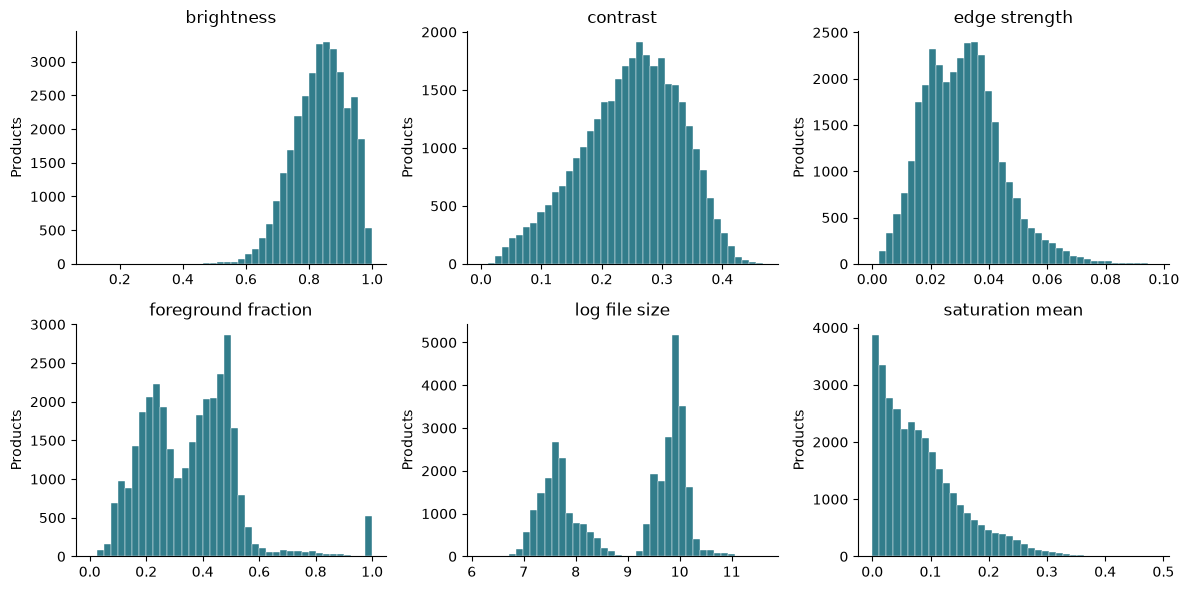

In [5]:
diagnostics = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/clean_slate_eda/teacher_image_diagnostics.csv.gz',
        keep_default_na=False)
assert set(diagnostics.id) == set(development.id)
quality_features = ['brightness','contrast','edge_strength','foreground_fraction',
    'log_file_size','saturation_mean']
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, feature in zip(axes.flat, quality_features):
    ax.hist(diagnostics[feature], bins=40, color='#327d8b', edgecolor='white', linewidth=0.3)
    ax.set(title=feature.replace('_',' '), ylabel='Products')
fig.tight_layout()
fig.savefig(FIGURES / "eda_image_quality.png", dpi=150, bbox_inches="tight")
plt.show()

### View a deterministic contact sheet across Gender and Usage

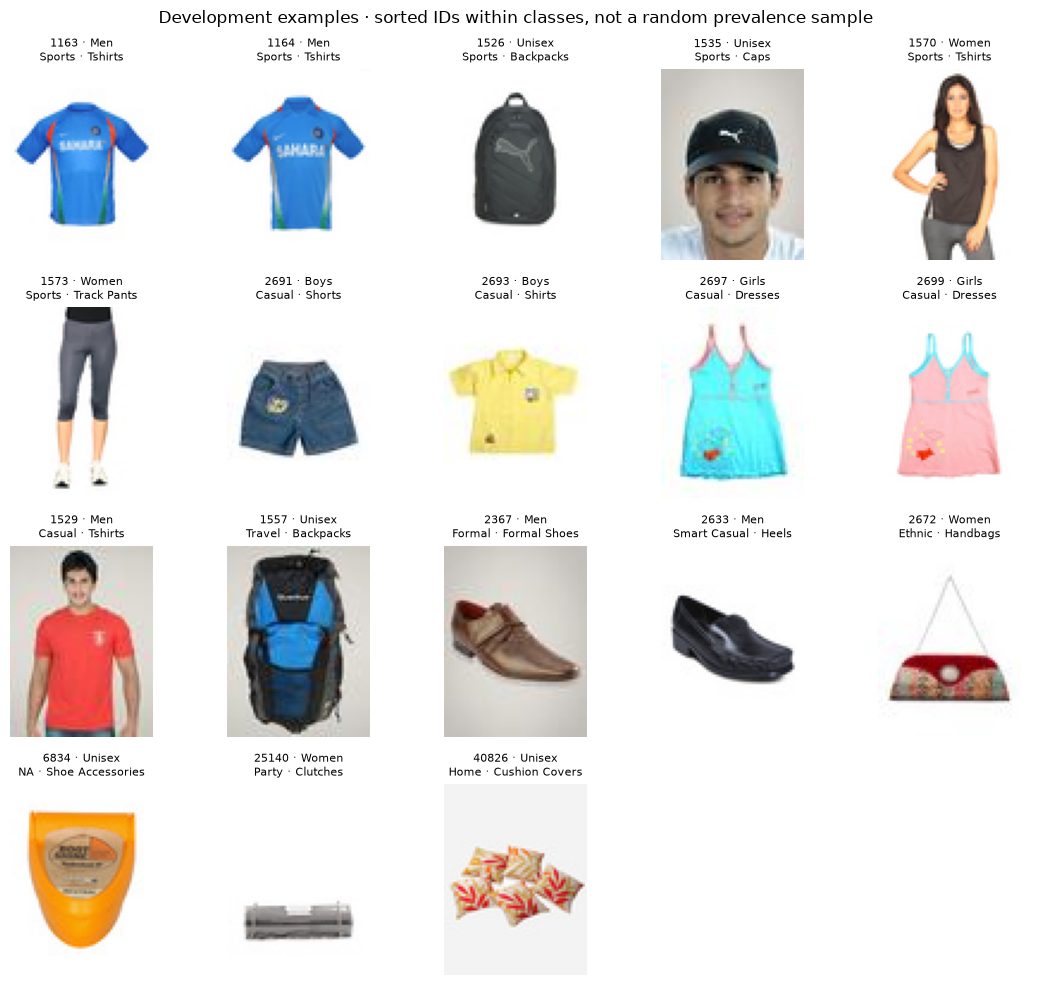

In [6]:
sample_rows = pd.concat([development.sort_values('id').groupby('gender').head(2),
                        usage_development.sort_values('id').groupby('usage').head(1)])
sample_rows = sample_rows.drop_duplicates('id').head(20)
fig, axes = plt.subplots(4, 5, figsize=(11, 10))
for ax in axes.flat:
    ax.axis('off')
for ax, row in zip(axes.flat, sample_rows.itertuples()):
    assert hashlib.sha256((REPO_DIR/row.path).read_bytes()).hexdigest() == row.sha256
    with Image.open(REPO_DIR/row.path) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'{row.id} · {row.gender}\n{row.usage or "blank"} · {row.articleType}', fontsize=8)
fig.suptitle('Development examples · sorted IDs within classes, not a random prevalence sample')
fig.tight_layout()
fig.savefig(FIGURES/'eda_contact_sheet.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation.** Most images have one centred item on white, but product scale, position, shadows and object type vary. There are 294 valid grayscale images and only 12 unusual geometries. The low native resolution leaves small cues such as straps, collars and shoe outlines fragile.

**Consequence.** Convert all inputs to RGB and keep the native 80×60 information. Fit normalisation only on the current training complement. Brightness and file size describe how images were acquired as well as the item itself; their predictive power would not by itself prove useful fashion understanding. The deterministic contact sheet covers labels, so it must not be read as their frequency in the dataset.

## 5. Shared EDA: transform risks

The small images made preprocessing consequential. The same products are shown under
stretching, cropping, padding and lighting changes to establish which transformations
preserve the item and which risk removing useful evidence.


### Compare image transforms on the same products

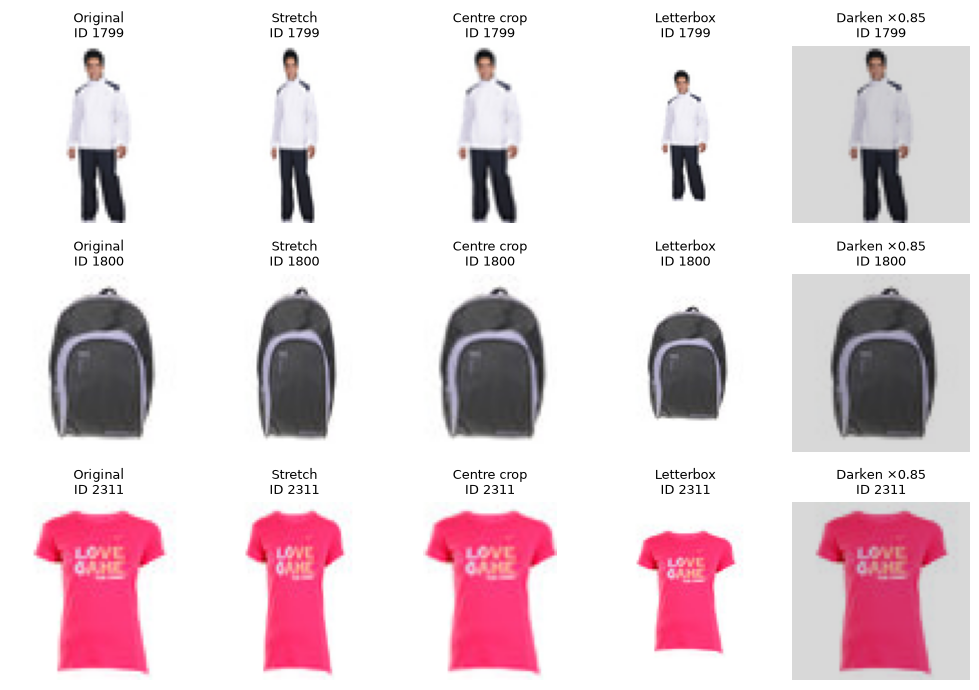

In [7]:
transform_rows = development.loc[development.width.ne(60)|development.height.ne(
    80)].sort_values('id').head(3)
fig, axes = plt.subplots(len(transform_rows), 5, figsize=(10, 7), squeeze=False)
for axes_row, row in zip(axes, transform_rows.itertuples()):
    with Image.open(REPO_DIR/row.path) as image:
        original = ImageOps.exif_transpose(image).convert('RGB')
        views = [original, original.resize((60,80)), ImageOps.fit(original,(60,80)),
                 ImageOps.pad(original,(60,80),color='white'), ImageEnhance.Brightness(
                     original).enhance(.85)]
    for ax, view, name in zip(axes_row, views, ['Original','Stretch','Centre crop',
        'Letterbox','Darken ×0.85']):
        ax.imshow(view)
        ax.set_title(f'{name}\nID {row.id}', fontsize=9)
        ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES/'eda_transform_risk.png', dpi=150, bbox_inches='tight')
plt.show()

**Baseline preprocessing and rationale**

| Choice | Exact baseline value | Reason |
|---|---|---|
| Input | `3×80×60` | Matches native image information |
| Geometry | EXIF, RGB, aspect preservation, LANCZOS letterbox only for unusual images | Avoid stretch and crop damage |
| Padding | White before scaling; neutral zero after standardisation | Match catalogue boundary without fitting padding |
| Normalisation | RGB mean/std fitted on current fold-training content pixels | Keep learned preprocessing inside the fold |
| Augmentation | None | Expose the raw train–validation and robustness gap |
| Validation | Deterministic transform only | Make candidate comparisons exact |

`(128,96)`, augmentation, another loss, or another transform is not a mandatory menu. It is a
single-factor child only when an accepted parent's evidence triggers it.

Stretching changes proportions; centre cropping can cut off the item. Letterboxing preserves it but moves boundaries and adds padding. These examples explain the baseline geometry rule; they do not establish that larger inputs add information. More pixels made from the same small JPEG cannot recover missing detail.

## 6. Shared EDA: class counts and independent families

Preserving image detail was only one requirement. The label counts revealed that the two
targets also differed in available support, especially when similar products were counted
as families rather than independent examples.


### Count products and families for both targets

development_product_count  development_family_count  \
target class                                                               
gender Boys                                684                       397   
       Girls                               543                       336   
       Men                               17753                     12345   
       Unisex                             1766                      1428   
       Women                             12027                      8401   
usage  Casual                            25151                     17637   
       Ethnic                             2183                      1351   
       Formal                             1949                      1016   
       Home                                  1                         1   
       NA                                   61                        49   
       Party                                12                        10   
       Smart Casual                         47                        37   
       Sports                             3346                      3020   
       Travel                               22                        22   

                     minimum_fold_training_products  untrainable_fold_count  
target class                                                                 
gender Boys                                     546                       0  
       Girls                                    433                       0  
       Men                                    14201                       0  
       Unisex                                  1411                       0  
       Women                                   9621                       0  
usage  Casual                                 20114                       0  
       Ethnic                                  1745                       0  
       Formal                                  1553                       0  
       Home                                       0                       1  
       NA                                        47                       0  
       Party                                      9                       0  
       Smart Casual                              37                       0  
       Sports                                  2675                       0  
       Travel                                    17                       0

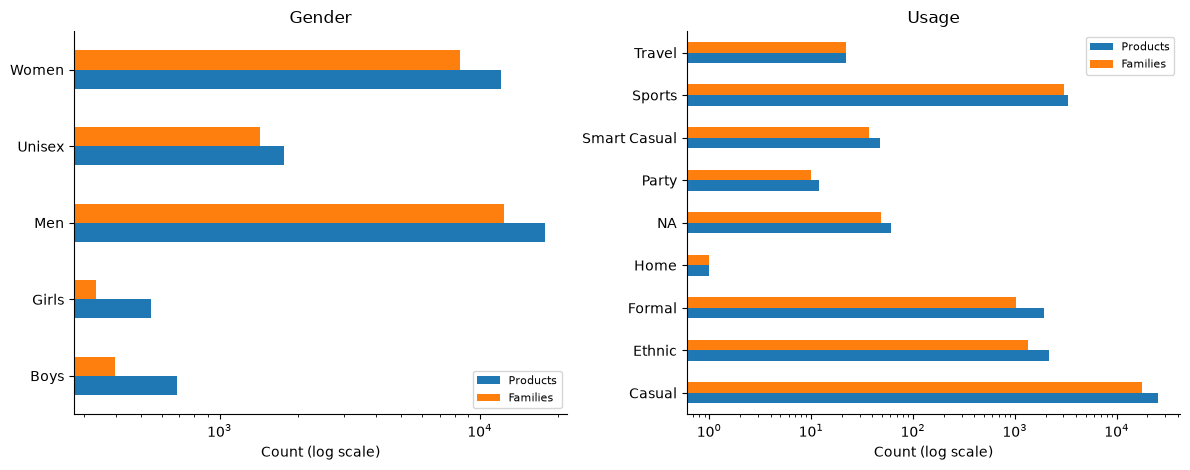

In [8]:
support = pd.read_csv(REPO_DIR / 'data/processed/development_class_summary.csv',
    keep_default_na=False)
support = support.loc[support.target.isin(['gender','usage'])].copy()
display(support[['target','class','development_product_count','development_family_count',
                 'minimum_fold_training_products','untrainable_fold_count']].set_index([
                     'target','class']))
fig, axes = plt.subplots(1,2,figsize=(12,4.8))
for ax, target in zip(axes,['gender','usage']):
    rows = support.loc[support.target.eq(target)].set_index('class')
    rows[['development_product_count','development_family_count']].rename(
        columns={'development_product_count':'Products',
            'development_family_count':'Families'}).plot.barh(ax=ax)
    ax.set(xscale='log', xlabel='Count (log scale)', ylabel='', title=target.title())
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "eda_class_support.png", dpi=150, bbox_inches="tight")
plt.show()

Gender ranges from 17,753 Men products to 543 Girls products. Usage ranges from 25,151 Casual products to one Home product. Macro-F1 gives each label the same weight, so mistakes on small classes matter even when accuracy is high. A family may contain very similar items; its members are not independent draws. Class weighting can change the penalty for an error, but it cannot create a second Home family.

This imbalance gave the study its two priorities: preserve performance on the common classes
while tracing failures on the small classes explicitly. It also set a limit on what model
changes alone could reasonably demonstrate.


## 7. Shared EDA: duplicate groups and fold support

These family relationships shaped the evaluation design. Keeping related products together
reduces the chance that a validation image is merely a close copy of a training image.
The saved fold support also exposes classes for which that separation leaves too little data.


### Check group crossings and show family sizes

,Count
Products,32773
Families,22905
Family fold crossings,0
Duplicate fold crossings,0


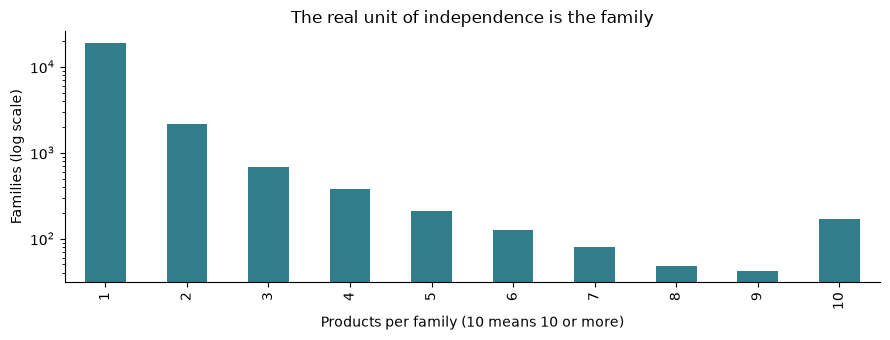

In [9]:
family_crossings = development.groupby('product_family_group').cv_fold.nunique()
duplicate_crossings = development.groupby('duplicate_group').cv_fold.nunique()
assert family_crossings.max() == 1 and duplicate_crossings.max() == 1
family_sizes = development.groupby('product_family_group').size()
display(pd.Series({'Products':len(development),'Families':len(family_sizes),
                   'Family fold crossings':int(family_crossings.gt(1).sum()),
                   'Duplicate fold crossings':int(duplicate_crossings.gt(1).sum())}).to_frame(
                       'Count'))
fig, ax = plt.subplots(figsize=(9,3.5))
family_sizes.clip(upper=10).value_counts().sort_index().plot.bar(ax=ax,color='#327d8b')
ax.set(yscale='log',xlabel='Products per family (10 means 10 or more)',
    ylabel='Families (log scale)',
       title='The real unit of independence is the family')
fig.tight_layout()
fig.savefig(FIGURES/'eda_family_sizes.png',dpi=150,bbox_inches='tight')
plt.show()

### Show every Usage class in every validation fold

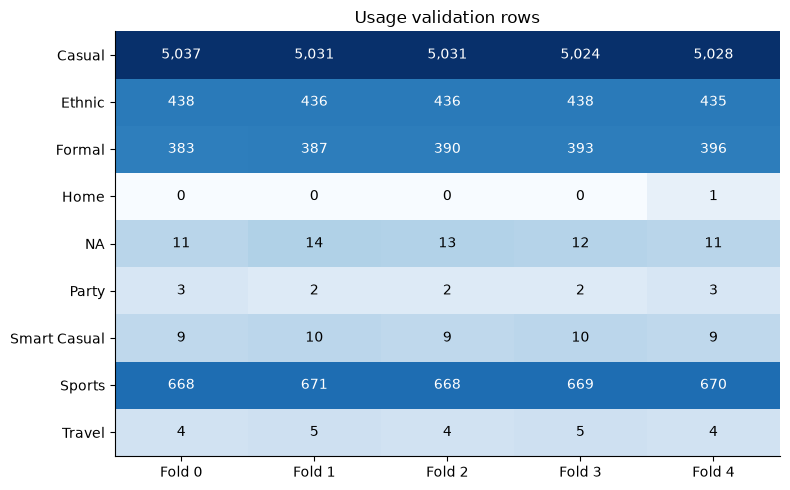

In [10]:
fold_support = support.loc[support.target.eq('usage')].set_index('class')
values = fold_support[[f'fold_{i}_validation_products' for i in range(5)]].to_numpy(int)
fig, ax = plt.subplots(figsize=(8,5))
ax.imshow(np.log1p(values),cmap='Blues',aspect='auto')
ax.set(xticks=range(5),xticklabels=[f'Fold {i}' for i in range(5)],
       yticks=range(len(fold_support)),yticklabels=fold_support.index,title='Usage validation rows')
for i,j in np.ndindex(values.shape):
    ax.text(j,i,f'{values[i,j]:,}',ha='center',va='center',color='white' if values[i,
        j]>300 else 'black')
fig.tight_layout()
fig.savefig(FIGURES/'eda_usage_fold_support.png',dpi=150,bbox_inches='tight')
plt.show()

**Family separation defined the comparison.** Exact bytes detect copied files, while reviewed perceptual matches and normalised product names catch a broader family. Broad name matches were reviewed because a generic shared name can wrongly merge different items. Conflicting labels and cross-role duplicate risks were handled before the split. The saved grouping is deliberately retained; model scores cannot justify regrouping a difficult example.

**Home exposed a structural limit.** Its single validation occurrence has no Home example in that fold's training complement. Zero recall there is a structural support failure, not evidence that a larger network would solve it. The official nine-class score still includes Home; the without-Home diagnostic must be named separately. Family bootstrap intervals resample families rather than pretend every near duplicate is independent.

## 8. Shared EDA: target relationships and shortcuts

After establishing family separation, we examined other associations a model might exploit.
Gender–Usage pairs, article types and acquisition cues help interpret later errors, while
remaining outside the image-only prediction input.


### Count the observed Gender–Usage pairs

Observed label pairs: 26 of 45


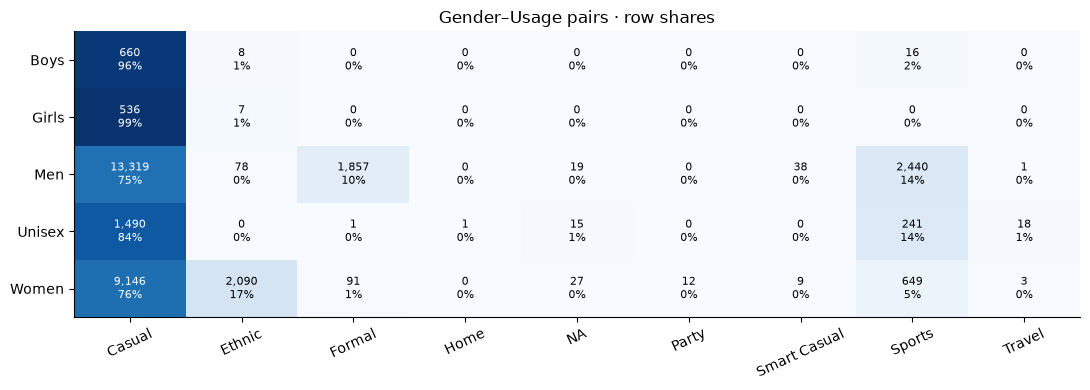

In [11]:
joint = pd.crosstab(usage_development.gender,usage_development.usage)
shares = joint.div(joint.sum(axis=1),axis=0)
fig, ax = plt.subplots(figsize=(11,4))
ax.imshow(shares,cmap='Blues',vmin=0,vmax=1,aspect='auto')
ax.set(xticks=range(len(joint.columns)),xticklabels=joint.columns,
       yticks=range(len(joint)),yticklabels=joint.index,title='Gender–Usage pairs · row shares')
ax.tick_params(axis='x',rotation=25)
for i,j in np.ndindex(joint.shape):
    ax.text(j,i,f'{joint.iloc[i,j]:,}\n{shares.iloc[i,j]:.0%}',ha='center',va='center',fontsize=8,
            color='white' if shares.iloc[i,j]>.55 else 'black')
print('Observed label pairs:',int(joint.gt(0).sum().sum()),'of',joint.size)
fig.tight_layout()
fig.savefig(FIGURES/'eda_target_relationships.png',dpi=150,bbox_inches='tight')
plt.show()

### Measure descriptive article-type and acquisition shortcuts

Target,gender,usage
Feature,,
articleType,78.54,90.04
file_size_band,54.17,76.75
mode,54.17,76.75
year,58.50,76.75


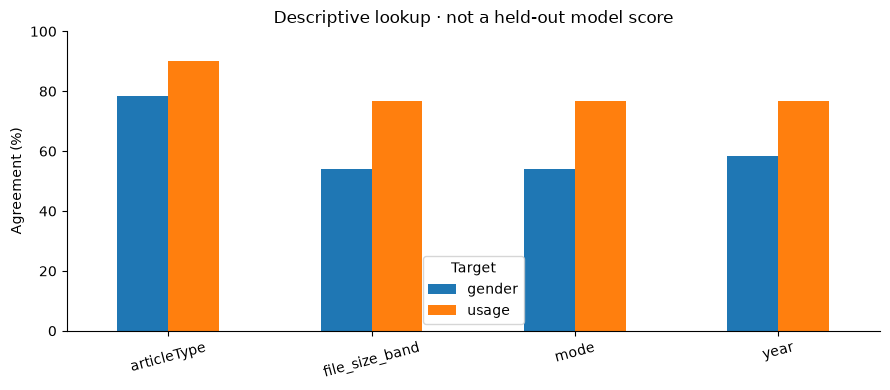

In [12]:
shortcut_rows = []
for target in ['gender','usage']:
    rows = development.loc[development[f'has_{target}_label'].eq(True)].copy()
    rows['file_size_band'] = pd.qcut(rows.file_size_bytes.astype(float),10,
        duplicates='drop').astype(str)
    for feature in ['articleType','year','mode','file_size_band']:
        counts = pd.crosstab(rows[feature],rows[target])
        shortcut_rows.append([target,feature,100*counts.max(axis=1).sum()/counts.to_numpy().sum()])
shortcuts = pd.DataFrame(shortcut_rows,columns=['Target','Feature',
    'Descriptive majority agreement (%)'])
display(shortcuts.pivot(index='Feature',columns='Target',
    values='Descriptive majority agreement (%)').round(2))
fig, ax = plt.subplots(figsize=(9,4))
shortcuts.pivot(index='Feature',columns='Target',
    values='Descriptive majority agreement (%)').plot.bar(ax=ax,rot=15)
ax.set(ylim=(0,100),ylabel='Agreement (%)',xlabel='',
    title='Descriptive lookup · not a held-out model score')
fig.tight_layout()
fig.savefig(FIGURES/'eda_shortcut_agreement.png',dpi=150,bbox_inches='tight')
plt.show()

Only 26 of 45 Gender–Usage pairs occur. This dependence does not license filling missing labels or hard-coding impossible pairs. Article type agrees with roughly 78.5% of Gender and 90.0% of Usage labels through a descriptive majority lookup. That is a shortcut warning, not cross-validated performance: the lookup used these same labels.

Year, mode and file-size bands can reflect catalogue sources or compression. Their high raw agreement can also come from the majority class alone. They are therefore slices for diagnosis, not proof of usable extra information. Article type remains outside the image-only input. A later type-to-Usage cascade must predict type from the image inside each training fold; it cannot read the row's true type at inference.

Together, the audit established a restrained starting point: learn from the product pixels,
keep related examples together, and examine performance beyond majority-class accuracy.


## 9. Start with the baseline

The audit suggested a compact model that preserved native image detail, but it did not
identify an optimal architecture. We therefore began with one bounded scratch CNN design
for both targets. Its training behaviour and held-family errors would determine which
changes were justified next.


**Exact primary learnable baseline**

The baseline used one fixed design, trained separately from scratch for each target:

```text
Conv3x3 3->32   + BatchNorm + ReLU + MaxPool2
Conv3x3 32->64  + BatchNorm + ReLU + MaxPool2
Conv3x3 64->128 + BatchNorm + ReLU + MaxPool2
Conv3x3 128->256 + BatchNorm + ReLU
Adaptive global average pooling
Linear 256->5 or Linear 256->9
```

**Depth and spatial reduction informed by the EDA**

The three pooling steps follow the observed native image size:

```text
80×60 -> 40×30 -> 20×15 -> 10×7
```

A `10×7` final grid still keeps separate evidence for small product regions. A fourth pool would
reduce these tiny inputs to about `5×3`, making it easier to lose straps, sleeves, collars, and
other edge details seen in the contact sheet. The fourth convolution therefore adds feature
capacity without another spatial reduction. With four `3×3` convolutions and three pools, one
final-grid position sees about a `38×38` source region; global average pooling then combines the
whole set of positions without tying a feature to one fixed product location.

**Channel counts as a capacity hypothesis**

The EDA justifies a small native-resolution CNN, three reductions, local-to-global feature
learning, and a bounded scratch capacity. It does **not** prove that `32,64,128,256` is optimal.
Those widths are a predeclared capacity hypothesis. As each pool removes about three quarters
of the spatial positions, the next block gets more feature channels while total activation size
continues to fall. The result is 390,181 trainable parameters for gender and 391,209 for usage.
The first curves then provide evidence about capacity and training duration; the EDA alone
does not establish that these choices are sufficient.

Batch normalization and ReLU are optimisation controls, not EDA discoveries. No dropout, class
weighting, augmentation, or pretrained weights are added because there is no parent-model
evidence for those changes yet.

Fixed recipe: Kaiming random initialisation, unweighted cross-entropy, AdamW, learning rate
`0.001`, weight decay `0.0001`, batch 128, 30 epochs, cosine decay to `0.00001`, no mixed
precision, no early stopping, final-epoch OOF checkpoint, seed 2753.

This is the architecture used by the saved baseline runs.
The trained model is the `final_epoch.pt` checkpoint inside each registered fold folder. The historical run audit checked each bundle. This notebook verifies the pinned registry and analysis sources before recomputing the displayed results.

**Lower bounds and integrity checks.** A fold-training majority predictor measures the class prior; a stratified predictor checks label order and the random seed. Bias-only and shuffled-label fits test for accidental label access. A tiny-batch overfit check establishes whether optimisation can fit a small known batch at all. These are code checks, not candidates for the final model. HOG + HSV logistic regression is the classical shape-and-colour reference. Dalal and Triggs [2]
motivate the edge descriptor; the colour features and classifier are local design choices. Scratch model weights are required; a pretrained comparison could only be an explicitly separate benchmark.

### Recompute the comparison from registered confusion counts

In [13]:
selected_stages = ['baseline', 'usage1']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
Usage E1 · Baseline,usage,"[0, 1, 2, 3, 4]",Original,32772,37.38,89.30


### Plot class gains and losses on the same folds

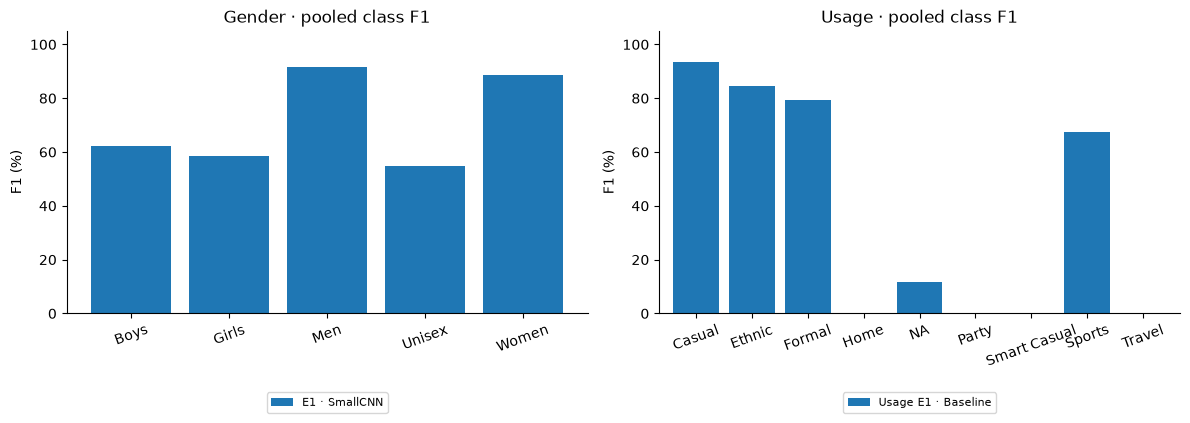

In [14]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "baseline_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### Read matched corruption results for every saved fold

In [15]:
robustness_keys=['baseline']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

,corruption,brightness_085,brightness_115,grayscale,jpeg_75,translation_003
Target,Stage,,,,,
gender,E1 · SmallCNN,-25.62,-3.86,-4.14,-4.16,-15.51


### Plot the change caused by each corruption

The fixed corruption checks follow the evaluation principle of Hendrycks and Dietterich [3]:
measure how predictions change under controlled image damage. The selected lighting, shift and
compression settings are adaptations for these small catalogue images, not the original benchmark.


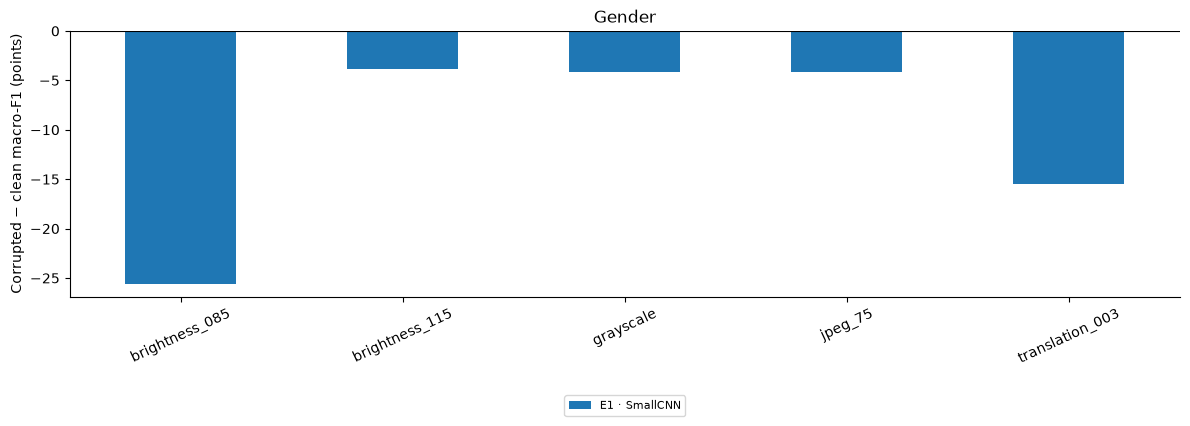

In [16]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "baseline_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Baseline diagnosis: curves, class collapse and confident errors

The baseline established different starting points for the two targets. Gender learned the
training images almost perfectly while retaining large validation errors. Usage achieved high
accuracy largely through common classes and missed several rare labels altogether. The curves,
class counts and selected mistakes below separate these patterns before the paths diverge.


### Read the baseline learning records

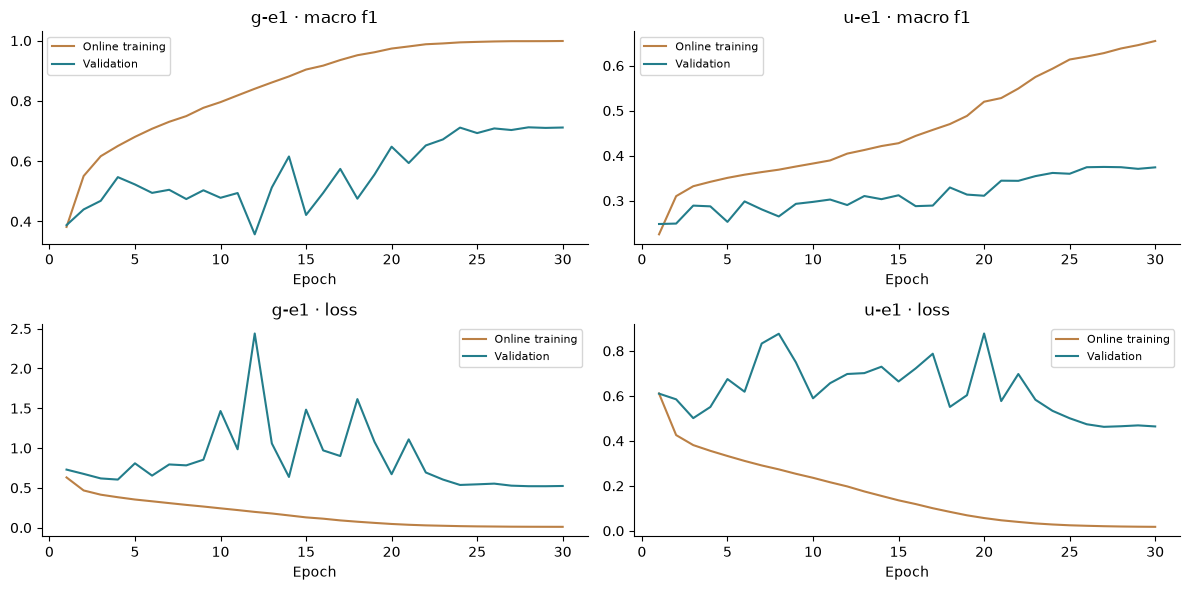

In [17]:
historical_curves = pd.read_csv(
    REPO_DIR / 'reports/task3/failure_review/evidence/all_model_curve_means.csv',
        keep_default_na=False)
fig, axes = plt.subplots(2,2,figsize=(12,6))
for column,model_id in enumerate(['g-e1','u-e1']):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    for row,metric in enumerate(['macro_f1','loss']):
        ax = axes[row,column]
        ax.plot(rows.epoch,rows['train_'+metric],label='Online training',color='#bb8045')
        ax.plot(rows.epoch,rows['validation_'+metric],label='Validation',color='#237d8b')
        ax.set(title=model_id+' · '+metric.replace('_',' '),xlabel='Epoch')
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "baseline_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Gender baseline diagnosis and next experiment**

**Decision: accept E1 as the reference parent, not as the final model.**

- Pooled OOF macro-F1 is **0.7118**. Fold scores are 0.6982, 0.7068, 0.7048,
  0.7207, and 0.7279: mean 0.7117, standard deviation 0.0109. The observed spread is 2.97 F1 points across
  the five family-safe folds; this does not measure variation across training seeds.
- The final online training macro-F1 is about 0.999 in every fold while OOF stays near 0.71.
  Final training loss averages about 0.0107. This is strong memorisation evidence.
- Validation loss reaches its minimum at epochs 3–6, then rises, while the best validation
  macro-F1 arrives at epochs 24–30. The epoch of lowest loss differs from the epoch of best F1 in these saved histories.
  Loss therefore cannot be substituted for the declared F1 criterion without changing the selection rule.
- Men F1 is 0.9167 and Women F1 is 0.8878. Boys, Girls, and Unisex are much weaker at
  0.6222, 0.5851, and 0.5470. Small classes have lower F1 here, but these counts alone do not establish the cause.
- The largest error routes are Women→Men (1,026), Men→Women (854), and Unisex→Men
  (516). Gender presentation is often weak or absent in product-only images.
- Mean macro-F1 change is −0.2562 under brightness ×0.85 and −0.1551 under a 3%
  translation. JPEG 75, grayscale, and brightness ×1.15 each cost about 0.04 or less.
- The selected 40 highest-confidence errors all have confidence at least 0.99. The gallery
  contains fragrances, watches, shoes, and other products with weak audience cues. Average
  ECE is only 0.0756, so the mean calibration score hides these extreme local mistakes.

The first historical child changed only one factor: add mild random brightness during training.
Architecture, input size, loss, optimiser, schedule, seed, folds, and final-epoch rule stay fixed.
Class weighting, translation, more pixels, and a new architecture are not added to this child.

**Usage baseline diagnosis and next experiment**

**Decision at this stage: keep E1 as the reference parent.** Its accuracy and equal-class performance must be judged separately.

- Pooled OOF macro-F1 is **0.3738**, or **0.4205** without the one-example Home class.
  Fold macro-F1 ranges from 0.3609 to 0.3960, with standard deviation 0.0121.
- Accuracy is 0.8930, but 25,151 of 32,772 valid rows (76.7%) are Casual. Accuracy and
  weighted-F1 mainly describe the large classes and hide rare-class failure.
- Casual, Ethnic, Formal, and Sports reach F1 values of 0.9329, 0.8463, 0.7939, and
  0.6731. NA reaches only 0.1176. Home, Party, Smart Casual, and Travel all score zero.
- The model predicts no Home, Party, or Smart Casual examples. It predicts Travel once,
  incorrectly. It sends 1,255 Sports, 450 Formal, 391 Ethnic, 55 NA, 36 Smart Casual,
  17 Travel, 9 Party, and the one Home row to Casual.
- Final training loss averages about 0.0177, but pooled OOF NLL is 0.4641. Validation loss
  bottoms at epochs 6–13 while the best macro-F1 appears at epochs 26–30. As with gender,
  the saved loss minima and F1 maxima select different epochs; loss alone does not implement the declared criterion.
- Mean robustness drops are smaller than gender: −0.0668 for darkening and −0.0642 for
  translation. This does not make Usage strong; its clean macro-F1 is already low.
- The error gallery shows real visual overlap. Sports and Casual shirts or shoes can look
  alike, and business labels such as Formal, Party, and Travel are not always visible from
  one product image. Weighting cannot create missing visual information.

The first eligible child changes only the loss to capped class-balanced cross-entropy. It uses
effective-number weights with `beta=0.999`, mean-one nonzero normalisation, cap 5, and only
the current fold's training counts. `Home` does not select or judge the child. Architecture,
input, augmentation, optimiser, schedule, seed, folds, and checkpoint rule stay fixed.

The brightness-only Gender trial did not establish the intended clean-score improvement. That side path did not determine the retained progression; the next retained test examined a different way of combining local image features. Usage retains the class-weighting test because it changed the accepted reference model.

### Read confident Gender mistakes on development images

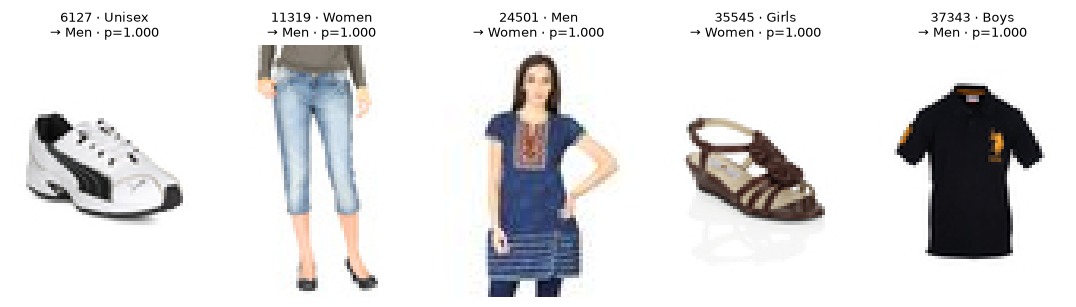

In [18]:
errors = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/baseline/gender/aggregate/failure_index.csv',
        keep_default_na=False)
errors = errors.loc[errors.true_label.ne(errors.predicted_label)]
errors = errors.sort_values(['confidence','id'],ascending=[False,True]).drop_duplicates(
    'true_label')
fig, axes = plt.subplots(1,5,figsize=(11,3))
for ax,row in zip(axes,errors.itertuples()):
    assert row.id in set(development.id)
    with Image.open(REPO_DIR/row.path) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'{row.id} · {row.true_label}\n→ {row.predicted_label} · p={
        row.confidence:.3f}',fontsize=9)
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES / "baseline_confident_errors.png", dpi=150, bbox_inches="tight")
plt.show()

The gallery selects the highest-confidence saved mistake per true Gender class, breaking ties by ID. It is an error audit, not an estimate of the error rate. A confident wrong watch or shoe supports the concern that the model uses catalogue associations. It does not prove which internal feature caused that one prediction.

## 11. Gender: pooling and photo sensitivity

**Pooling became the next controlled change.** The baseline fits its training families almost perfectly, yet misses Boys, Girls
and Unisex more often than Men and Women. Adding capacity is not the first response to that pattern.
One possible weakness is how the network combines local evidence: global average pooling gives
every final-grid position equal weight, which can dilute a small but useful region.

The GeM proposal has a research basis in Radenović, Tolias and Chum [4], who introduce
generalised-mean pooling to combine average-like and max-like feature aggregation. This gives
a reason to test whether stronger local responses preserve small fashion cues. Their evidence
concerns image retrieval; our hypothesis adapts the pooling operation to scratch classification
and fixes its power instead of learning it.

E6 changes only that pooling step to fixed GeM:
`mean(max(x, 1e-6)^3)^(1/3)`. Strong activations receive more weight. The fixed power `p=3`
adds no trainable parameters; the convolution blocks, loss, optimiser, 30-epoch budget, seed and
folds remain the same. Improvement in minority classes without a common-class or robustness loss
would support this mechanism. A higher aggregate score alone would not show why it improved.

The table keeps the three milestones on **all five folds and original labels**. Read E1→E6 as
the pooling comparison and E6→G2 as the later translation comparison. These are separate runs.

In [19]:
selected_stages = ['baseline', 'gem', 'translation']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
E6 · GeM pooling,gender,"[0, 1, 2, 3, 4]",Original,32773,73.35,89.32
G2 · Translation,gender,"[0, 1, 2, 3, 4]",Original,32773,75.02,90.34


**Gender E6 — a real gain, but memorisation remains**

GeM improved four of five folds and every class. The largest F1 gains over E1 were Unisex
(+0.0424) and Boys (+0.0338). Accuracy rose from 0.8768 to 0.8932, NLL fell from 0.5237 to
0.4325, and all five corruption scores improved. The product-family bootstrap lower bound is
above zero, so the gain is not explained by treating related images as independent rows.

This does not fix overfitting. Finished training macro-F1 is still 0.99995 and the mean
train-validation gap is 0.2666. Unisex recall is only 0.5181; 514 Unisex rows become Men and
288 become Women. Mixed-label-family NLL worsened from 1.5753 to 1.6275 even while
consistent-family NLL improved. GeM helps visual summarisation, but it cannot resolve conflicting
or visually unclear labels.

The performance gain has a memory cost: peak memory was 476.0 MB versus at most
450.5 MB for E1, about 5.7% higher. We retain E6 as evidence that pooling helps, while
reporting that extra memory alongside its score. Its near-perfect training fit and remaining
class errors justify further investigation before choosing a final model.

**The remaining shift sensitivity motivated translation.** Pooling improved visual summarisation but left near-perfect clean
training F1 and a large validation gap. The baseline corruption test also showed strong sensitivity
to small shifts. G2 tests whether varying training placement reduces reliance on fixed catalogue
alignment; validation images stay unchanged. Zhang [6] shows that ordinary CNN downsampling
can make predictions sensitive to small shifts. This supports the mechanism behind the test;
the local corruption audit supplies the reason to test it here.

On screen folds 0 and 4, G2 improves all five pooled class scores and reduces translation-corruption
loss from 13.99 to 1.69 F1 points. That supports improved tolerance to the tested shifts. Yet its clean gap
falls only from 27.70 to 24.84 points and dark-image behaviour worsens. The saved predictions are less sensitive to the tested shifts; other failures remain.

**The additional folds do not establish a clear improvement.** G2 reaches 75.02% pooled F1 across all five folds, versus E6's 73.35%. But the fresh folds 1–3 improve by only 1.2947 points with a family-bootstrap 95% interval of −0.3554 to +2.8650. The lower bound is not above zero. The dark-image induced loss is also 3.1993 points worse than E6. The uncertain gain on additional folds and worse dark-image performance prevent us from treating the higher pooled score as an unqualified improvement.

**Translation informed later work despite its limits.** The two-fold screen sharply reduced translation corruption loss, consistent with a placement sensitivity. It did not close the clean fit gap, and it exposed a separate lighting weakness. Later named candidates reuse that useful mechanism while retaining G2's historical rejection. They do not retroactively call it an accepted finalist.

**The alternatives narrowed the investigation.** Residual connections [5] motivated the TinyResNet
comparison, but its 71.21% F1 was almost unchanged from E1,
with a family interval crossing zero and worse confidence and translation behaviour. Best-checkpoint
early stopping reached 74.12% but left a 25.82-point clean gap, missing its 24.66-point target.
Those results rule out simple architecture or checkpoint fixes under the tested recipes; they do
not need separate full sections. The compact table below recomputes the original Gender alternatives from their registered
confusion counts. A higher score alone does not erase the class errors, uncertainty and robustness losses described above.

The wider architecture search tested different ways of retaining information. CompactBlurCNN
used low-pass filtering before downsampling, consistent with the anti-aliasing method in [6].
TinyHRNet drew on parallel high-resolution representations [7]. The Gender audience helper
used related supervision, motivated by multitask learning [8], with task competition [9] as a
reason to demand local gains. These were small project adaptations, not exact reproductions
of the published networks. Their saved results did not justify replacing the retained path.

A later AdamW trial changed weight decay from 0.0001 to 0.01, drawing on decoupled weight-decay
regularisation [10]. Its limited effect kept the focus on more targeted changes. The numerical
setting was a local test choice, not a value established by that paper.


In [20]:
compact_rows = []
for key in ['baseline', 'brightness', 'balance', 'resnet', 'blur',
            'gem', 'hrnet', 'early', 'filter', 'aux']:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    metrics = runs.metrics_json.map(json.loads)
    cm = np.sum([row['confusion_matrix'] for row in metrics], axis=0)
    denominator = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denominator,
                   out=np.zeros(len(cm)), where=denominator > 0)
    compact_rows.append([stage['label'], ', '.join(map(str, stage['folds'])),
                         stage['labels'], int(cm.sum()),
                         100*f1.mean(), 100*np.trace(cm)/cm.sum()])
display(pd.DataFrame(compact_rows, columns=[
    'Experiment', 'Folds', 'Label basis', 'Images', 'Macro-F1 (%)', 'Accuracy (%)'
]).set_index('Experiment').round(2))


,Folds,Label basis,Images,Macro-F1 (%),Accuracy (%)
Experiment,,,,,
E1 · SmallCNN,"0, 1, 2, 3, 4",Original,32773,71.18,87.68
E2 · Brightness,"0, 1, 2, 3, 4",Original,32773,69.89,87.30
E3 · Class weights,"0, 1, 2, 3, 4",Original,32773,70.81,87.32
E4 · TinyResNet,"0, 1, 2, 3, 4",Original,32773,71.21,87.71
E5 · CompactBlurCNN,"0, 1, 2, 3, 4",Original,32773,70.69,88.72
E6 · GeM pooling,"0, 1, 2, 3, 4",Original,32773,73.35,89.32
E7 · TinyHRNet,"0, 1, 2, 3, 4",Original,32773,70.25,87.35
E8 · Early stopping,"0, 1, 2, 3, 4",Original,32773,74.12,89.12
E9 · Semantic filter,"0, 1, 2, 3, 4",Original,32773,74.51,89.30


### Check a different model family on matched screen folds

HOG describes local edges without learning an image representation. A support vector machine
(SVM) then separates these fixed features. It tests whether a simpler feature model can generalise
better than the CNN, whose training fit is already very high.

Use only folds **0 and 4** for both models. The full-population screen matters: a balanced-sample
probe changes the class mix and cannot be compared directly with these naturally imbalanced folds.

In [21]:
selected_stages = ['gem04', 'hog_g']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E6 · GeM pooling,gender,"[0, 4]",Original,13110,72.30,89.19
Gender S1 · HOG SVM,gender,"[0, 4]",Original,13110,66.08,85.28


**Result and meaning.** HOG-SVM reaches 66.08% macro-F1, below the matched GeM reference.
Fixed edge features did not retain enough useful class separation under this screen. This supports
keeping learned CNN features; it does not prove every possible classical model would fail.
Only two folds and one seed were tested, so the result is a screening decision, not a full confirmation.

The separate scratch transformer screen also fell short. Together, these screens supported
returning to the CNN's fit gap, image sensitivity and labels before adding more capacity.

### Test each part of the final augmentation recipe

These steps need separate interpretation even though their scores share one table. Drop30 hides
30% of classifier features during training, testing whether the classifier relies too strongly on
specific combinations. This follows the dropout mechanism of Srivastava et al. [11];
the placement after GeM and rate 0.30 are local choices. Mild darkening then targets the lighting weakness; grayscale on 10% of
training images tests whether shape cues survive without colour. Each child retains its parent's
other settings. Validation is clean and deterministic.

The comparison uses **folds 0 and 4 and original labels**. Clean finished-model audits are used
for the gaps below. Online training scores on augmented images would make the gap look smaller
without measuring the same task as clean validation.

In [22]:
selected_stages = ['translation04', 'dropout', 'dark', 'gray']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
G2 · Translation,gender,"[0, 4]",Original,13110,74.57,90.31
Dropout 0.30,gender,"[0, 4]",Original,13110,75.42,90.16
Add mild darkening,gender,"[0, 4]",Original,13110,74.22,90.22
Add grayscale 10%,gender,"[0, 4]",Original,13110,74.79,90.09


**Drop30: partial progress.** The clean gap falls from G2's 24.84 to about 21.24 points.
Hiding features is consistent with reducing reliance on individual feature combinations, but the
remaining gap is still large and the dark-image weakness persists. Drop30 is a diagnostic base,
not yet a final model.

**Darkening: a targeted repair with a cost.** Dark-image behaviour improves, but clean pooled F1
falls from 75.43% to 74.22% and the gap grows from 21.24 to 22.34 points. A corruption gain
does not imply a clean-image gain. The larger clean gap and remaining grayscale weakness mean
it cannot be described as an unqualified improvement.

**Grayscale: one weakness reduced, another remains.** Random grayscale conversion improves
performance on grayscale images, but the clean training–validation gap remains
21.33 points. The grayscale test supports reduced sensitivity to removing colour; it does not identify
the cause of every unseen-family error. The final recipe retains this mechanism through later named candidates; the earlier failure
is still recorded.

**The remaining gap motivated label review.** The CNN can fit the training rows, several nuisance sensitivities have
been reduced, and class errors remain. That pattern makes weak or conflicting target labels worth
checking. It does not prove the labels are wrong: rare support and ambiguous product appearance
are competing explanations. The next audit therefore uses an explicit name rule and reports both
label bases, rather than relabelling whatever the model gets wrong.

The remaining screens examined foreground masking, component weights, weight decay, a narrower
head, stronger dropout and article-group weights. The table below shows their saved development scores, fold sets and label basis.
These are different parent comparisons; do not treat the table as one controlled experiment.

In [23]:
compact_rows = []
for key in ['gem04', 'g1', 'translation04', 'g3', 'gd1', 'wd1',
            'narrow', 'dropout', 'dark', 'drop45', 'gray', 'group']:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    metrics = runs.metrics_json.map(json.loads)
    cm = np.sum([row['confusion_matrix'] for row in metrics], axis=0)
    denominator = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denominator,
                   out=np.zeros(len(cm)), where=denominator > 0)
    compact_rows.append([stage['label'], ', '.join(map(str, stage['folds'])),
                         stage['labels'], int(cm.sum()),
                         100*f1.mean(), 100*np.trace(cm)/cm.sum()])
display(pd.DataFrame(compact_rows, columns=[
    'Experiment', 'Folds', 'Label basis', 'Images', 'Macro-F1 (%)', 'Accuracy (%)'
]).set_index('Experiment').round(2))


,Folds,Label basis,Images,Macro-F1 (%),Accuracy (%)
Experiment,,,,,
E6 · GeM pooling,"0, 4",Original,13110,72.30,89.19
G1 · Foreground mask,"0, 4",Original,13110,72.95,89.26
G2 · Translation,"0, 4",Original,13110,74.57,90.31
G3 · Component weights,"0, 4",Original,13110,72.45,89.20
GD1 · Mild darkening,"0, 4",Original,13110,74.12,90.29
Weight decay 0.001,"0, 4",Original,13110,74.87,90.45
Narrow 64 channels,"0, 4",Original,13110,73.60,90.01
Dropout 0.30,"0, 4",Original,13110,75.42,90.16
Add mild darkening,"0, 4",Original,13110,74.22,90.22


## 12. Review the labels

The image-focused changes left a substantial Gender gap. This led to a closer examination
of the target definition: some supplied categories conflicted with explicit product-name cues.
The review introduced a fixed, separately reported label basis so that label changes could
be distinguished from improvements learned by the network.


### A new label basis must be named

Some product names clearly state a gender that conflicts with the supplied category.
The frozen `single_explicit_gender_cue_v1` rule creates a task-only label variant from those names.
Ambiguous names are left alone. Canonical labels are not overwritten.

This changes both training targets and development scoring labels. A jump from the previous table
therefore cannot be called a model-only gain. Original-label and corrected-label scores must remain separate in development comparisons.
The next table, class-gap chart and error gallery trace the effect of that review and locate
the errors that remained.

Label-quality research supports investigating suspect targets rather than assuming that every
training label is correct. Confident Learning [12] uses out-of-sample probabilities to estimate
label issues. Our explicit product-name rule is a different, documented intervention: it does
not implement that algorithm, and model confidence alone does not authorise a label change.


### Compare models on the same corrected-label basis

,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
G2,75.12,94.41,19.32
E6,72.87,94.89,22.01
Gray10,75.49,91.84,16.35
NameTruth,79.44,96.80,17.38


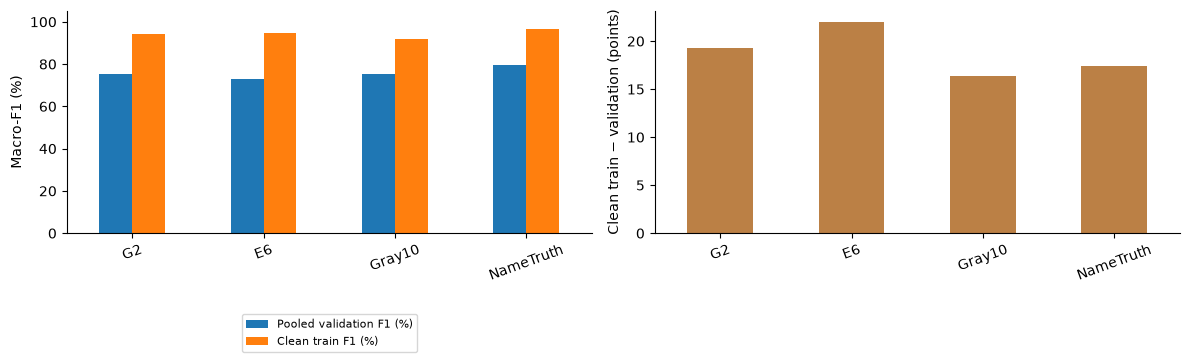

In [24]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_name_truth_result_20260906/verified_summary.csv',
        keep_default_na=False)
audit = audit.loc[audit.basis.eq('name_truth')].copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'mean_train_f1',
    'mean_gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_result_20260906.png", dpi=150, bbox_inches="tight")
plt.show()

**The label change required a separate comparison.** Re-scoring an old model against corrected labels changes the measured training gap even without retraining it. That accounting change cannot be claimed as a learned improvement. The fixed rule uses only one explicit gender cue; ambiguous names stay unchanged. The name-corrected training candidate is then compared against parents on that same basis. The label correction does not certify that every remaining label is visually knowable.

### Locate the classes that contribute to the clean fit gap

model,G2,Gray10,NameTruth
class_name,,,
Boys,3.98,3.65,4.29
Girls,5.21,4.46,4.76
Men,1.10,0.93,0.95
Unisex,7.54,5.98,6.08
Women,1.49,1.33,1.30


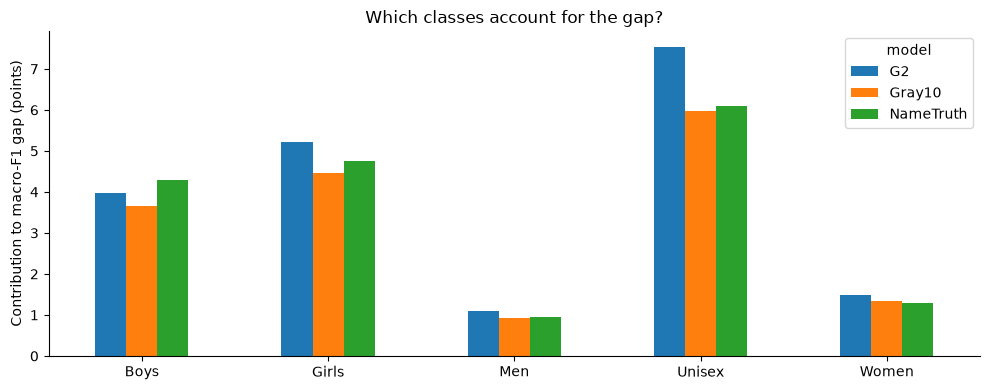

In [25]:
class_gaps=pd.read_csv(
    REPO_DIR / ('reports/task3/gender_name_truth_deep_rev'
        'iew_20260906/class_gap_contributions.csv'), keep_default_na=False)
gap_plot=class_gaps.groupby(['model','class_name']).contribution_to_macro_gap.mean().unstack(0).mul(100)
display(gap_plot.round(2))
fig,ax=plt.subplots(figsize=(10,4))
gap_plot.plot.bar(ax=ax,rot=0)
ax.set(ylabel='Contribution to macro-F1 gap (points)',xlabel='',
       title='Which classes account for the gap?')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_class_gap.png", dpi=150, bbox_inches="tight")
plt.show()

Boys, Girls and Unisex contribute about 87.1% of the remaining macro gap. The model misses 337 of 707 Unisex products in the deep review. Watches, fragrances and shoes can have weak audience cues while their training types carry strong label priors. Good training fit on these groups and poor held-family performance is consistent with learning catalogue-specific associations.

The unchanged-label subset also improves (about 76.98% to 78.45% F1), with a barely positive uncertainty bound. That supports some real learning beyond score changes on relabelled rows. It is still one seed and two selected folds; class priors, family variation and label ambiguity remain competing explanations.

### View the audited remaining errors

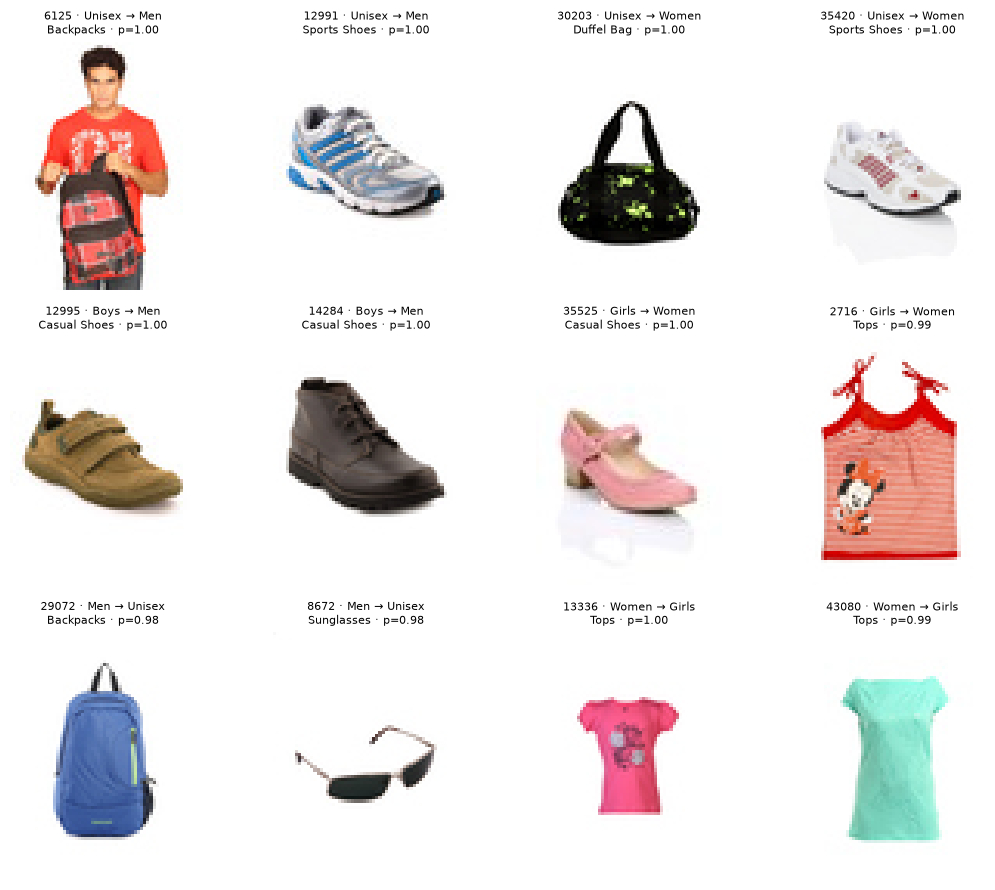

In [26]:
visual_cases=pd.read_csv(
    REPO_DIR / 'reports/task3/gender_name_truth_deep_review_20260906/visual_cases.csv',
        keep_default_na=False)
fig,axes=plt.subplots(3,4,figsize=(11,9))
for ax,row in zip(axes.flat,visual_cases.itertuples()):
    assert row.id in set(development.id)
    with Image.open(REPO_DIR/row.path) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'{row.id} · {row.true_label} → {row.predicted_label}\n{
        row.articleType} · p={row.confidence:.2f}',fontsize=8)
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_error_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

**The examples locate the remaining difficulty.** The selected errors include bags, shoes and clothing whose
intended audience may depend on catalogue wording or sizing not visible in a small image. They
illustrate plausible failure modes; this selected gallery cannot estimate their frequency or prove
that all such errors are unavoidable. The class-gap audit, rather than the gallery alone, supports
the focus on Boys, Girls and Unisex. Since the corrected-label model still overfits those classes,
MixUp is the next test of memorisation under the same corrected-label basis.

## 13. Add MixUp

The reviewed labels clarified part of the target, but the remaining gap still concentrated
in Boys, Girls and Unisex. MixUp addressed this remaining memorisation by blending training
examples and their targets, while preserving the corrected-label comparison basis.

Zhang et al. [13] motivate this test by training on convex combinations of images and labels,
encouraging smoother behaviour between examples. We test alpha 0.20 locally; published gains
on other datasets do not establish that mixing preserves useful cues in tiny fashion images.


### Inspect the audited MixUp 0.20 improvement

,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
G2,75.12,94.41,19.32
E6,72.87,94.89,22.01
Gray10,75.49,91.84,16.35
NameTruth,79.44,96.80,17.38
MixUp,80.89,93.81,12.91


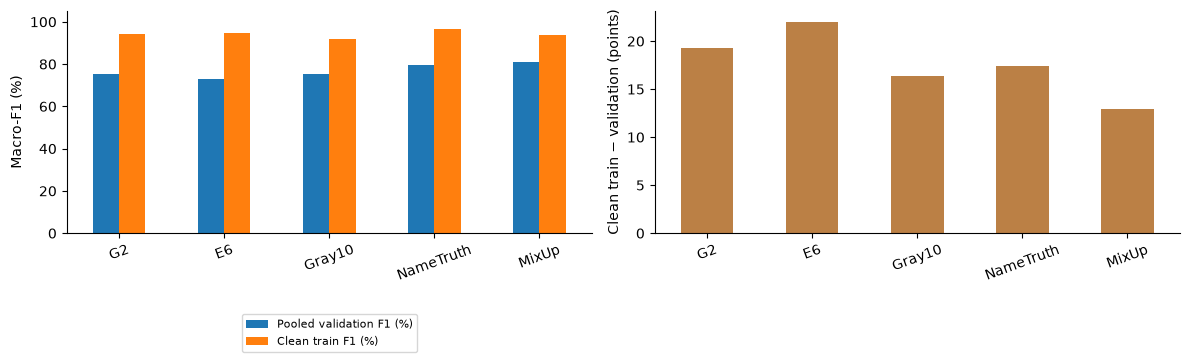

In [27]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_mixup_result_20260906/verified_summary.csv',
        keep_default_na=False)
audit = audit.loc[audit.basis.eq('name_truth')].copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'mean_train_f1',
    'mean_gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "mixup_result_20260906.png", dpi=150, bbox_inches="tight")
plt.show()

**Hypothesis.** Soft targets on blended training examples discourage an overconfident boundary tightly fitted to each image. Blending occurs only inside the current training batch; validation remains clean.

**Result.** With alpha 0.20, matched pooled F1 rises from 79.44% to 80.89%, and the clean gap falls from 17.38 to 12.91 points. Much of the F1 gain comes from Boys and Girls; the total error count changes little. Macro-F1 can rise because errors shift away from small classes even when accuracy barely moves.

**Stronger blending did not improve the trade-off.** The stronger setting reaches about 79.87% in the matched IEEE audit and a 12.20-point mean gap. The gap improves by only 0.72 points while pooled F1 falls by about 1.02 points, fold 0's gap worsens, and Unisex does not improve. More blending can remove class-specific evidence as well as discourage memorisation. The saved registry score is about 79.94%; this small numeric-basis difference is kept explicit. Alpha 0.20 stays the parent.

The retained alpha 0.20 setting thus became the basis for the next experiment. The remaining
gap motivated a change to the weight update, while the failed stronger blend discouraged
treating additional regularisation as an automatic improvement.


## 14. Choose the SAM25 trade-off

MixUp improved the matched score and reduced the gap, yet a sizeable difference between
training and validation remained. The next experiment added SAM's weight-perturbation update.
Its 30-epoch result then motivated a separate run with a fixed 25-epoch stopping point.

Foret et al. [14] motivate SAM by seeking weights with low loss in their neighbourhood,
which provides a distinct test after changing the training examples with MixUp. The paper
supports the update rule; the 25-epoch budget and accepted F1–gap trade-off come from our
development results, not from a published fashion benchmark.


### From the SAM update to a fixed 25-epoch recipe

SAM checks the loss after a small weight perturbation, then makes one update from that second gradient.
It keeps the same architecture and MixUp. The 30-epoch run and its learning curves led to a new fixed
25-epoch recipe, retaining the original 30-epoch cosine schedule. This choice used development evidence.
The final checkpoint is epoch 25, not a best epoch chosen afterwards.

### Inspect the SAM30 epoch diagnostic

,epoch,mean_train_f1,mean_validation_f1,mean_gap,pooled_validation_f1,unisex_correct,unisex_support,unisex_recall
0,10,0.7840,0.7322,0.0518,0.7327,252,707,0.3564
1,15,0.8352,0.7727,0.0625,0.7740,319,707,0.4512
2,20,0.8727,0.7796,0.0931,0.7804,330,707,0.4668
3,25,0.8980,0.7986,0.0994,0.7986,361,707,0.5106
4,30,0.9030,0.7943,0.1087,0.7943,356,707,0.5035


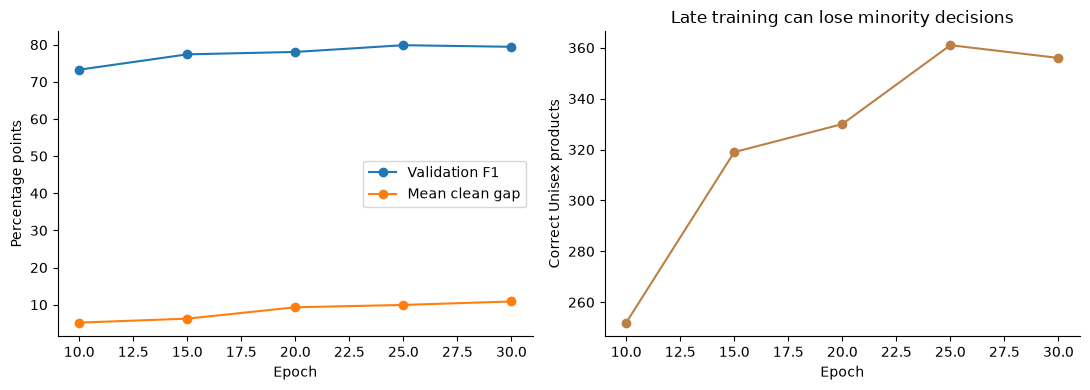

In [28]:
sam_epochs=pd.read_csv(
    REPO_DIR / 'reports/task3/gender_sam_result_20260906/epoch_summary.csv', keep_default_na=False)
display(sam_epochs.round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(sam_epochs.epoch,100*sam_epochs.pooled_validation_f1,marker='o',label='Validation F1')
axes[0].plot(sam_epochs.epoch,100*sam_epochs.mean_gap,marker='o',label='Mean clean gap')
axes[0].set(xlabel='Epoch',ylabel='Percentage points')
axes[0].legend()
axes[1].plot(sam_epochs.epoch,sam_epochs.unisex_correct,marker='o',color='#bb8045')
axes[1].set(xlabel='Epoch',ylabel='Correct Unisex products',
    title='Late training can lose minority decisions')
fig.tight_layout()
fig.savefig(FIGURES / "sam_epoch_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

### Read the matched screen trade-off

,model,validation_f1,mean_gap,mean_clean_train_f1,unisex_correct,unisex_support,errors,nll,ece_15
0,MixUp 0.2,0.8089,0.1291,0.9381,361,707,1192,0.2703,0.0132
1,SAM 30,0.7943,0.1086,0.9029,356,707,1237,0.2788,0.0203
2,SAM 25,0.7986,0.0993,0.8979,361,707,1245,0.2828,0.0279


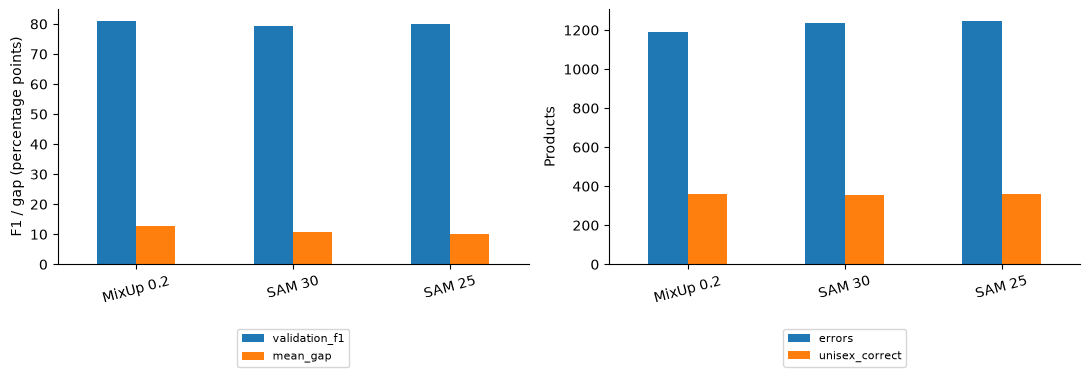

In [29]:
sam_screen=pd.read_csv(REPO_DIR / 'reports/task3/gender_sam25_result_20260906/comparison.csv',
    keep_default_na=False)
display(sam_screen.round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
sam_screen.set_index('model')[['validation_f1','mean_gap']].mul(100).plot.bar(ax=axes[0],rot=15)
sam_screen.set_index('model')[['errors','unisex_correct']].plot.bar(ax=axes[1],rot=15)
axes[0].set(ylabel='F1 / gap (percentage points)',xlabel='')
axes[1].set(ylabel='Products',xlabel='')
for ax in axes:
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.23))
fig.tight_layout()
fig.savefig(FIGURES / "sam25_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

SAM30 lowers the clean gap to 10.86 points but scores 79.43% F1. It loses five Unisex detections compared with MixUp (356 versus 361 of 707). The epoch diagnostic suggests a late minority-class cost. It is evidence for a new fixed-budget hypothesis, rather than a retrospective search for the best validation checkpoint.

SAM25 fixes 25 epochs before its separate run; it is **not a best epoch** extracted from SAM30. It reaches 79.86% F1 and a 9.93-point clean gap, with 361 Unisex detections. It still makes 53 more total mistakes than MixUp and has lower class F1 across the five classes. We retained SAM25 because it reduced the clean gap by 2.98 points relative to MixUp,
restored the five Unisex detections lost by SAM30, and improved F1 from SAM30's 79.43% to 79.86%.
The cost was 1.03 F1 points relative to MixUp. This combination justified taking SAM25
forward to the five-fold audit; a smaller gap alone would not justify the choice. There is no universal rule that a gap below 10 points makes a model good; this is the recorded project trade-off.

## 15. Confirm the fixed recipe on five folds

The two-fold screen made SAM25 worth investigating, but could not establish how it behaved
on the remaining folds. We retained the recipe and examined those additional folds separately
before pooling all five. This extended the development evidence without hiding its origin
in repeated screening.


### Recompute the fold summary from the saved final evaluation

,train_f1,validation_f1,gap
fold,,,
0,89.32,79.81,9.52
1,89.32,79.36,9.96
2,90.16,78.60,11.56
3,90.21,80.83,9.38
4,90.27,79.92,10.35


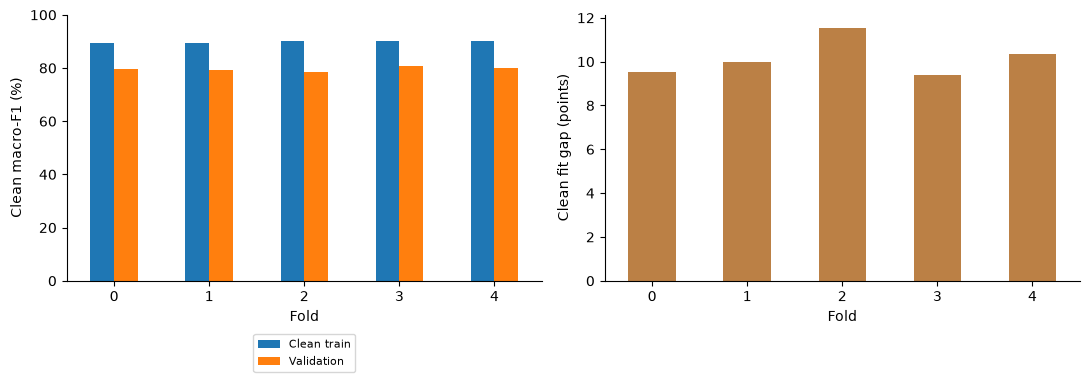

In [30]:
cv_summary=json.loads((
    REPO_DIR/'reports/task3/gender_sam25_cv_result_20260906/cv_summary.json').read_text())
fold_review=pd.read_csv(
    REPO_DIR / 'reports/task3/gender_sam25_cv_result_20260906/fold_review.csv',
        keep_default_na=False)
display(fold_review.set_index('fold')[['train_f1','validation_f1','gap']].mul(100).round(2))
fig,axes=plt.subplots(1,2,figsize=(11,4))
fold_review.set_index('fold')[['train_f1','validation_f1']].mul(100).plot.bar(ax=axes[0],rot=0)
fold_review.set_index('fold').gap.mul(100).plot.bar(ax=axes[1],rot=0,color='#bb8045')
axes[0].set(ylabel='Clean macro-F1 (%)',ylim=(0,100),xlabel='Fold')
axes[0].legend(['Clean train','Validation'],fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.18))
axes[1].set(ylabel='Clean fit gap (points)',xlabel='Fold')
fig.tight_layout()
fig.savefig(FIGURES / "sam25_cv_folds.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding.** The audited IEEE result is 79.73% pooled macro-F1, with a 10.15-point mean clean gap. Fold scores range from 78.60% to 80.83%. These are five development folds, not five independent test sets.

**Finding.** The extra folds 1, 2, and 3 score 79.63% pooled F1. Unisex remains the weakest class. This extends the evidence beyond the original two-fold screen, but does not establish stability across seeds or erase repeated use of development data.

With that wider development evidence in place, the study moved from choosing a recipe to
constructing its single full-development checkpoint. The following histories document the
fold fits before the separate refit record.


### Read each fold learning history

In [31]:
history_paths = ['reports/task3/gender_sam25_cv_result_20260906/fold0/history.csv',
    'reports/task3/gender_sam25_cv_result_20260906/fold1/history.csv',
        'reports/task3/gender_sam25_cv_result_20260906/fold2/history.csv',
            'reports/task3/gender_sam25_cv_result_20260906/fold3/history.csv',
                'reports/task3/gender_sam25_cv_result_20260906/fold4/history.csv']
final_histories=[]
for fold,path in enumerate(history_paths):
    rows=pd.read_csv(REPO_DIR / str(path).replace('reports/task3_', 'reports/task3/', 1))
    rows['fold']=fold
    final_histories.append(rows)
final_history=pd.concat(final_histories,ignore_index=True)
assert final_history.fold.nunique()==5

### Plot the five development-fold training histories

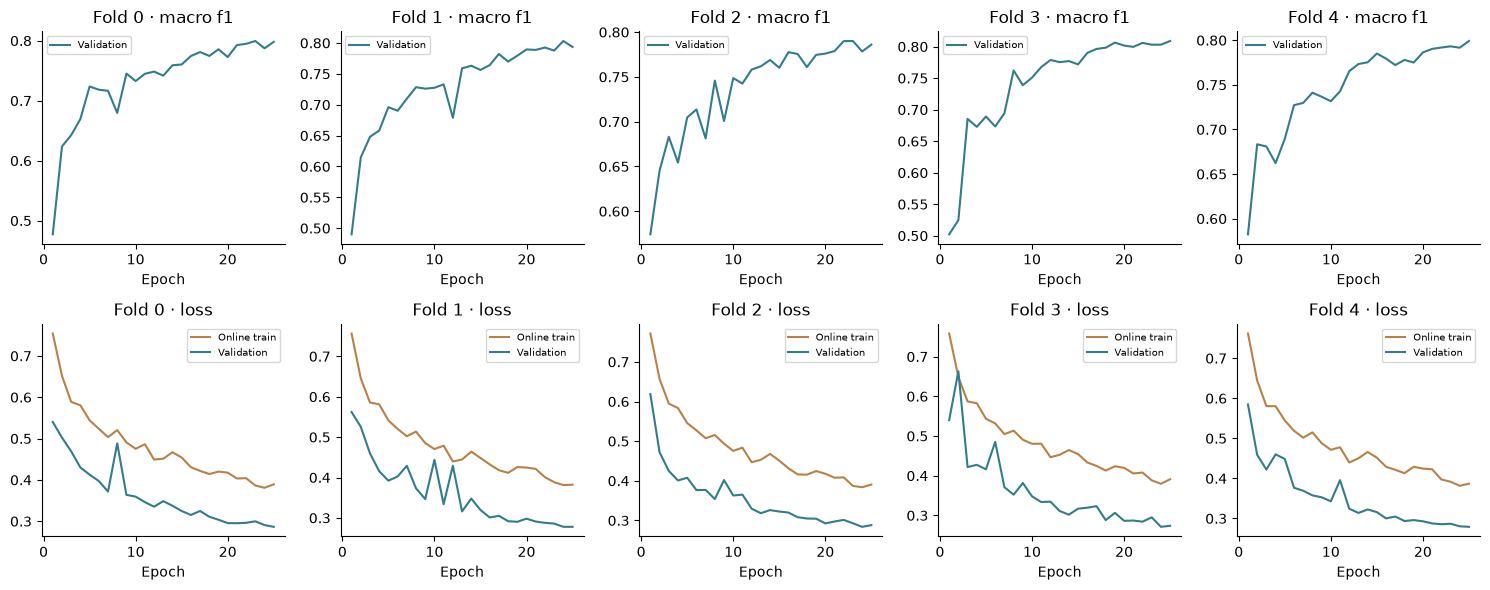

In [32]:
fig,axes=plt.subplots(2,5,figsize=(15,6))
for fold in range(5):
    rows=final_history.loc[final_history.fold.eq(fold)]
    for row,metric in enumerate(['macro_f1','loss']):
        if rows['train_'+metric].notna().any():
            axes[row,fold].plot(rows.epoch,rows['train_'+metric],label='Online train',
                color='#bb8045')
        axes[row,fold].plot(rows.epoch,rows['validation_'+metric],label='Validation',
            color='#327d8b')
        axes[row,fold].set(title=f'Fold {fold} · {metric.replace("_"," ")}',xlabel='Epoch')
        axes[row,fold].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURES / "sam25_full_curves.png", dpi=150, bbox_inches="tight")
plt.show()

The registry training-runtime result is 79.74% pooled F1; the matched IEEE audit is 79.73%. Fold F1 ranges from 78.60% to 80.83%, with a 10.15-point mean clean gap. Fresh folds 1–3 score 79.63% pooled. The history uses runtime values and online augmented training; the clean gap above uses saved evaluation-mode predictions. Loss generally improves toward the end, but a gap remains. Stable folds do not remove the selection bias from many development trials.

The MixUp histories deliberately leave online training macro-F1 undefined for mixed targets. The top row therefore shows validation F1 only. The bottom row shows both training and validation losses. Clean training F1 comes from the separate evaluation-mode audit above; no missing training curve is filled in.

### Refit the fixed Gender recipe on all development images

A refit trains fresh weights on all development rows after the recipe is set. The earlier five-fold
study checked the method. This later run makes the single model used for final predictions.
It includes **all 32,773 development images**, with the saved name-corrected labels, and trains
for exactly **25 epochs**. There is no validation split, early stopping or best-epoch choice.

The table reads the completed `results/runs.csv` row from a checked Drive registry snapshot.
It records completion and cost, not accuracy on unseen images. The original five-fold OOF
scores stay attached to the fold models; they are not scores for this new checkpoint.


In [33]:
from fashion.task3_gender_final import verify_gender_final

GENDER_FINAL = REPO_DIR/'reports/task3/gender_final_sam25_refit_20260907'
gender_final_manifest = verify_gender_final(REPO_DIR)
gender_refit_runs = pd.read_csv(GENDER_FINAL/'refit_runs.csv', keep_default_na=False)
assert len(gender_refit_runs) == 1 and gender_refit_runs.status.eq('complete').all()
gender_run = gender_refit_runs.iloc[0]
gender_train_metrics = json.loads(gender_run.metrics_json)
display(pd.DataFrame([{
    'Model': 'SAM25 single refit', 'Images': int(gender_run.training_product_count),
    'Epochs': gender_train_metrics['epochs_completed'],
    'Validation images': int(gender_run.validation_product_count),
    'Train minutes': float(gender_run.train_seconds)/60,
    'Peak GPU MiB': gender_train_metrics['peak_memory_bytes']/1024**2,
    'Parameters': int(gender_run.parameter_count),
    'Checkpoint bytes': int(gender_run.checkpoint_bytes),
}]).set_index('Model').round(2))

,Images,Epochs,Validation images,Train minutes,Peak GPU MiB,Parameters,Checkpoint bytes
Model,,,,,,,
SAM25 single refit,32773,25,0,7.74,456.04,390181,1579253


### Read the full-development training behaviour

MixUp blends examples and their labels, so its loss is a training diagnostic. The perturbed loss
is SAM's second pass on the same mixed batch. Neither curve is validation loss or clean training
F1. The learning-rate panel checks the fixed 30-epoch cosine schedule stopped after epoch 25.


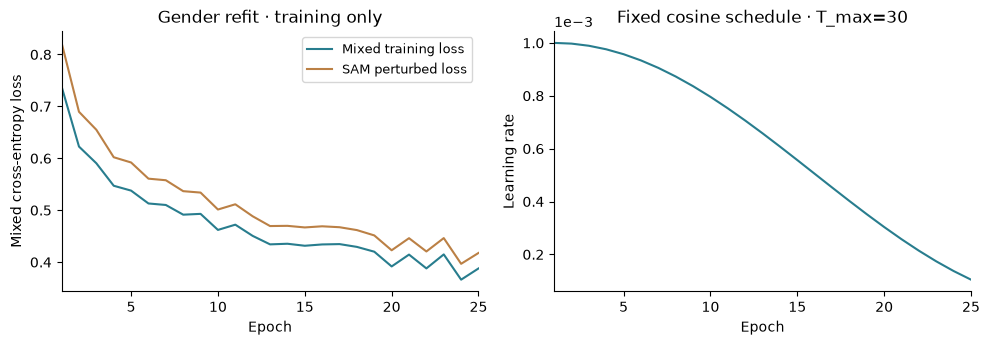

In [34]:
GENDER_REFIT = TASK3_EVIDENCE_ROOT/'gender_sam25_refit_20260907'
gender_history = pd.read_csv(GENDER_REFIT/'history.csv', keep_default_na=False)
assert gender_history.epoch.tolist() == list(range(1, 26))
assert gender_history.training_rows.eq(32773).all()
assert gender_history.optimizer_steps.eq(257).all()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
axes[0].plot(gender_history.epoch, gender_history.train_mixed_loss,
             label='Mixed training loss', color='#287d8e')
axes[0].plot(gender_history.epoch, gender_history.sam_perturbed_loss,
             label='SAM perturbed loss', color='#bb8045')
axes[0].set(xlabel='Epoch', ylabel='Mixed cross-entropy loss',
            title='Gender refit · training only', xlim=(1, 25))
axes[0].legend(fontsize=9)
axes[1].plot(gender_history.epoch, gender_history.learning_rate, color='#287d8e')
axes[1].set(xlabel='Epoch', ylabel='Learning rate', xlim=(1, 25),
            title='Fixed cosine schedule · T_max=30')
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
fig.tight_layout()
fig.savefig(FIGURES/'gender_refit_training.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding.** Mixed training loss falls from **0.7382 to 0.3878**; SAM's perturbed loss falls
from **0.8223 to 0.4177**. The last mixed loss is above epoch 24's 0.3662. This does not justify
switching checkpoints: batches, augmentations and mixing vary, and epoch 25 was fixed in advance.
The run completes 257 updates per epoch, each with two SAM gradient passes, in **7.74 minutes**.
Peak reported GPU memory is **456.04 MiB**. These are one run's costs, not repeated benchmarks.

Training progress does not show whether generalisation improved. There is no validation curve
for this refit, and no meaningful online F1 for blended labels. Scoring its development rows would
measure training exposure. The previous clean train–validation gap remains evidence about the
fold models; it cannot be assigned to the full-development checkpoint.


### Freeze the single Gender SAM25 refit

**Final Gender model: the single full-development SAM25 refit, epoch 25.** The five-model
average is now a historical comparison. The recipe follows the development trade-off above:
SAM25 scores 79.86% against MixUp's 80.89% on the matched screen, but reduces the
clean gap from 12.91 to 9.93 points, retains 361 Unisex detections and improves F1 over SAM30's 79.43%.
We judged that combination sufficient to justify the 1.03-point F1 loss and retained it for
the five-fold audit. The resulting 79.73% pooled F1, including 79.63% on additional folds
1–3, supports the fixed recipe beyond the screen. There is no matched five-fold comparison
showing that it outperforms MixUp alone. The owner accepted the refit on 7 September 2026 after evaluation review.
The later holdout comparison and final judgement are in the Task 3 evaluation notebook (`04_task3_final_evaluation.ipynb`).

Keep the scratch 390,181-parameter SmallCNN, channels 32/64/128/256, GeM p=3 and dropout 0.30.
Training uses MixUp alpha 0.20, SAM rho 0.05, seed 2753, batch 128, AdamW at 0.001 and weight
decay 0.0001. The cosine schedule keeps **T_max=30**, minimum rate 0.00001 and a fixed stop at
epoch 25. Keep the saved translation (up to two pixels, probability 0.5), mild darkening
(probability 0.25) and grayscale (probability 0.10) recipe.

For prediction, use RGB height 80 and width 60, EXIF orientation, aspect-preserving LANCZOS
resize and centred letterboxing. Apply the refit's saved full-development mean and standard
deviation to content pixels, and zero the padding. Use evaluation mode, then softmax and argmax
in the saved class order. No augmentation, MixUp, SAM update or fold averaging runs at inference.


In [35]:
print('Final Gender run:', gender_final_manifest['run_id'])
print('Checkpoint:', gender_final_manifest['checkpoint']['path'])
print('SHA-256:', gender_final_manifest['checkpoint']['sha256'])
print('Class order:', ', '.join(gender_final_manifest['class_names']))
gender_normalization = json.loads(
    (REPO_DIR/gender_final_manifest['normalization']['path']).read_text())
display(pd.DataFrame({'Channel': ['R', 'G', 'B'],
    'Mean': gender_normalization['mean'], 'Standard deviation': gender_normalization['std']
}).set_index('Channel').round(6))
assert gender_normalization['fit_scope'] == 'all_development_content_pixels_only'
assert gender_normalization['padding_excluded'] is True

Final Gender run: t3_gender_name_truth_mixup_alpha020_sam005_epoch25_refit_20260907T061926Z_db0fc1ee
Checkpoint: results/evidence/task3/gender_sam25_refit_20260907/final_epoch.pt
SHA-256: 41a5f5ea027805e8edbbf667d080564776ca9873d9146e0dec15c0d4bec2b272
Class order: Boys, Girls, Men, Unisex, Women


,Mean,Standard deviation
Channel,,
R,0.849999,0.271111
G,0.833254,0.282661
B,0.827607,0.286203


**Limits and handoff.** The code above reads and displays the accepted checkpoint identity,
class order and normalization. The completed training record and curves are shown in this section. The old five-fold
manifest and the refit's original training receipt remain unchanged.

One model now serves each image. That reduces five forward passes to one, but measured app
speed and robustness of the new checkpoint are still unknown. Audience ambiguity and the small
Boys, Girls and Unisex classes remain limits. The accepted model supports catalogue suggestions
with review; a photo cannot establish a person's gender or an item's exclusive audience.

The Gender path therefore ended with a compact refit and an explicit audience-label limit.
The Usage path below returns to the baseline and follows a different failure pattern: whole
rare classes received few or no correct predictions.


## 16. Usage: class weighting, then translation

**The Usage path began with rare-class failure.** Returning to the same baseline, E1 has high accuracy while failing the rare classes. Weighted
cross-entropy increases the cost of minority mistakes. Cui et al. [15] motivate weighting by
the effective number of samples, allowing for diminishing benefit from additional examples
of a common class. E2 uses effective-number weights
(`beta=0.999`, cap 5, mean-one nonzero normalisation), computed only from each fold's training
counts. The SmallCNN, input, optimiser, seed, 30 epochs and final-checkpoint rule remain fixed.
Home has insufficient support to judge the child, but remains in the official nine-class score.

**The next change addressed position sensitivity.** E2 can still rely on catalogue alignment. E8 keeps E2's loss
and adds translation with probability 0.5, independently sampling integer shifts from −2 to +2
pixels on each axis, with white fill. The shift-sensitivity mechanism in [6] supports this
focused intervention; the exact policy follows the local failure audit. Validation and inference stay unchanged. The comparison measures position tolerance alongside clean minority performance, so that
a robustness gain cannot substitute for class-level evidence.

The main table keeps E1, E2 and E8 on the same five teacher folds. These are the steps that change
the direction of the investigation; the compact table after the interpretation also displays the other original tuning runs.

### Diagnose what the baseline is learning

E1 predicts 23,923 of 25,151 Casual items correctly, but only four of 61 NA items and none
of the 12 Party, 47 Smart Casual, 22 Travel or single Home item. Its 89.30% accuracy therefore
hides a much weaker 37.38% equal-class F1. Sports also matters: 1,255 Sports items become
Casual, far more errors than the entire rare-class population. The problem is both rare-label
coverage and overlap between common occasions.

Class weights test whether ordinary cross-entropy gives too little influence to rare labels.
That is a narrower claim than saying weighting fixes the dataset. One Home example cannot
support a reliable class estimate, and a product photo may not distinguish Casual from Travel.
The deterministic gallery below shows one most-confident baseline error per available true class.
It illustrates failures; it is deliberately selected and does not estimate their frequency.
Confidence is rounded to three decimals; a displayed 1.000 does not imply certainty.


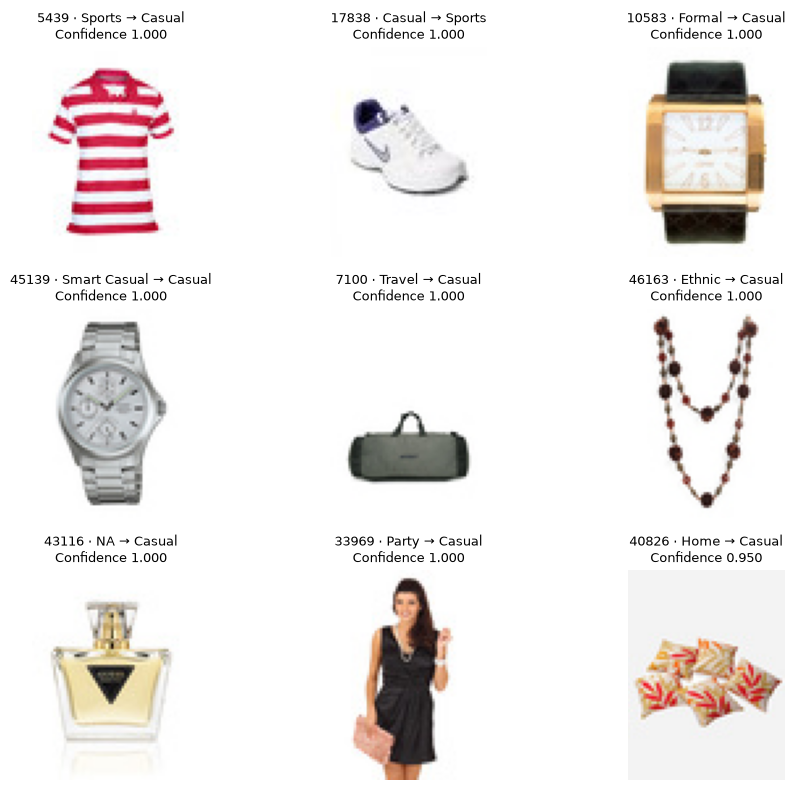

In [36]:
usage_errors = pd.concat([pd.read_csv(
    TASK3_EVIDENCE_ROOT/'baseline/usage'/run_id/'oof_predictions.csv',
    keep_default_na=False) for run_id in evidence_lock['stages']['usage1']['run_ids']])
usage_errors = usage_errors.loc[usage_errors.true_label.ne(usage_errors.predicted_label)]
usage_examples = usage_errors.sort_values(
    ['confidence', 'id'], ascending=[False, True]).drop_duplicates('true_label')
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
for ax in axes.flat:
    ax.axis('off')
for ax, row in zip(axes.flat, usage_examples.itertuples()):
    assert row.id in set(usage_development.id)
    with Image.open(REPO_DIR/row.path) as product:
        ax.imshow(product.convert('RGB'))
    ax.set_title(f'{row.id} · {row.true_label} → {row.predicted_label}\n'
                 f'Confidence {row.confidence:.3f}', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES/'usage_baseline_errors.png', dpi=150, bbox_inches='tight')
plt.show()


**The gallery supports an error audit.** A confident wrong occasion label shows that confidence
is not a guarantee of correctness. It does not prove a label is wrong or reveal which feature
the network used. Keep the supplied Usage labels, quantify the errors on all development rows,
then test the loss change on the same saved folds.


### Recompute the comparison from registered confusion counts

In [37]:
selected_stages = ['usage1', 'usage2', 'usage8']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Usage E1 · Baseline,usage,"[0, 1, 2, 3, 4]",Original,32772,37.38,89.30
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E8 · Translation,usage,"[0, 1, 2, 3, 4]",Original,32772,41.94,88.85


**Usage E2 — accept class-balanced cross-entropy**

Usage E2 reached **0.4082 pooled macro-F1**, up **0.0344** from 0.3738, and reached
**0.4592 without Home**, up **0.0387** from 0.4205. Balanced
accuracy improved from 0.3571 to 0.3826 while ordinary accuracy moved only from 0.8930
to 0.8915. This is the intended trade: better treatment of supported minority classes with
almost no loss on the majority-dominated accuracy.

Calibration also improved: NLL fell from 0.4641 to 0.3428 and ECE fell from 0.0672 to
0.0331. Final fold macro-F1 values were 0.4086, 0.3818, 0.4362, 0.3999, and 0.3950.
Their standard deviation was 0.0203, higher than E1's 0.0121, so the gain is useful but
not equally strong in every fold.
The fold scores show improvement in four of five folds; only fold 4 is effectively flat. The
learning curves still show a large train-validation gap, but the mean validation macro-F1 remains well below the online training score. This supports keeping the new loss while testing one small
regularisation change next.


Casual F1 stayed flat and Sports F1 improved, so the gain did not come solely from sacrificing these common classes. The largest gains came
from NA and Travel, but Party, Smart Casual, and the one-row Home class remain unlearned.
Formal also fell by 0.0180. Weighting helped the classes that had some learnable evidence; it
could not invent evidence for tiny classes or remove semantic overlap. **E2 is accepted as the
new Usage parent, but not yet declared final.** The saved confusion counts confirm the remaining
failure: Home, Party, and Smart Casual still collapse mostly into Casual; Travel is detected only
three times and NA only ten times.

**The class plot identifies the source of the gain.** The gains need to occur in supported minority classes, not
only Casual. Look for NA and Travel improving from E1 to E2, and for the zero or near-zero
rare-class scores that survive both changes. The graph is evidence of where the benefit occurs,
not proof that the rare-class problem has been solved.

### Compare learning behaviour and fold stability

The curves below use the saved mean of five fold histories. They are epoch diagnostics;
the final comparison above pools confusion counts and is a different calculation. E8's online
training images are translated, while validation images are unchanged. Online training F1 is
therefore not a clean training-set evaluation. E2/E8 use weighted loss and E1 does not: compare
loss trends within a panel, not loss heights between recipes.


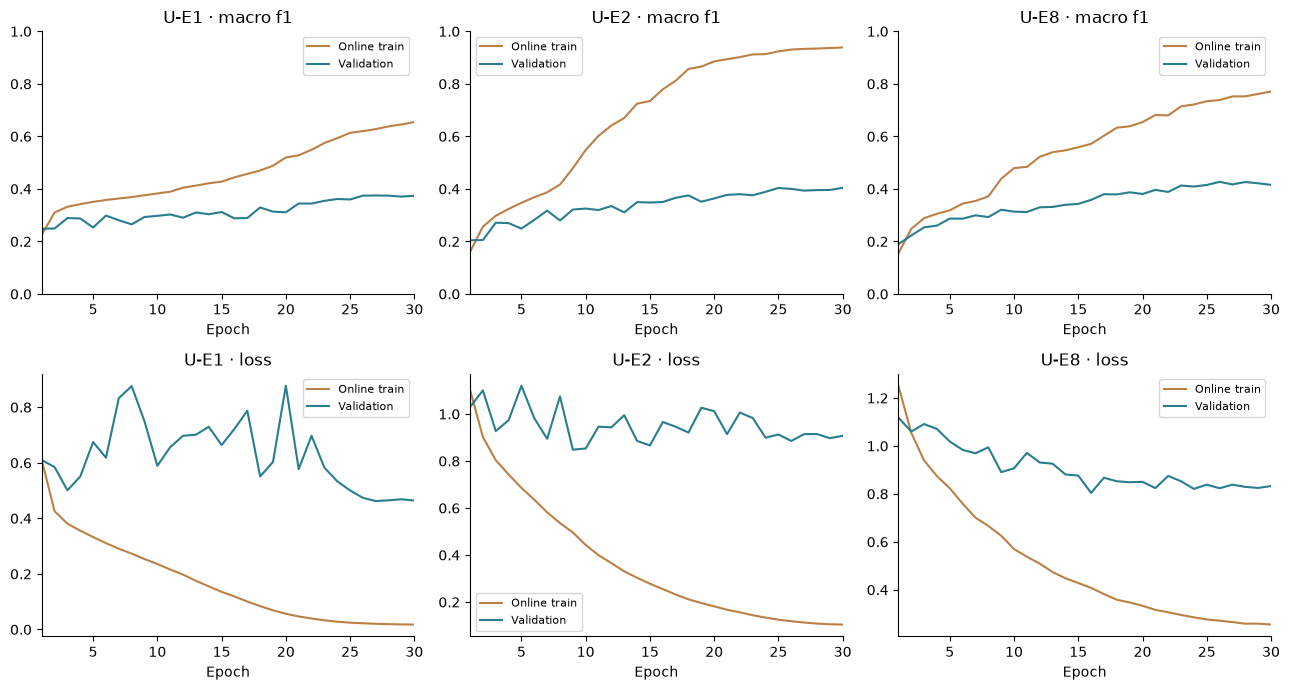

In [38]:
usage_curve_rows = historical_curves.loc[
    historical_curves.model_id.isin(['u-e1', 'u-e2', 'u-e8'])].copy()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for column, name in enumerate(['u-e1', 'u-e2', 'u-e8']):
    rows = usage_curve_rows.loc[usage_curve_rows.model_id.eq(name)].sort_values('epoch')
    for row, metric in enumerate(['macro_f1', 'loss']):
        ax = axes[row, column]
        ax.plot(rows.epoch, rows['train_'+metric], label='Online train', color='#bb8045')
        ax.plot(rows.epoch, rows['validation_'+metric], label='Validation', color='#287d8e')
        ax.set(title=name.upper()+' · '+metric.replace('_', ' '), xlabel='Epoch', xlim=(1, 30))
        if metric == 'macro_f1':
            ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES/'usage_development_curves.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation.** At epoch 30, E2's mean online training F1 is 93.85%, while mean validation
F1 is 40.43%. Weighting makes minority training examples easier to fit, but most of that fit
does not carry to held-out families. E8's online training F1 is lower, 77.07%, while validation
is 41.55%. This is consistent with a harder augmented training task; it is not, by itself,
proof that the clean generalisation gap closed. The clean-fit audit later in this notebook
keeps that distinction visible. None of these curves licenses choosing a new best epoch:
the reported E1/E2/E8 checkpoints all use the fixed 30-epoch rule.

### Check whether each saved fold benefits


In [39]:
usage_fold_scores = pd.DataFrame(fold_rows, columns=['Model', 'Target', 'Fold', 'F1 (%)'])
usage_fold_grid = usage_fold_scores.pivot(index='Fold', columns='Model', values='F1 (%)')
usage_fold_grid = usage_fold_grid.rename(columns={
    evidence_lock['stages'][key]['label']: name
    for key, name in [('usage1', 'E1'), ('usage2', 'E2'), ('usage8', 'E8')]})
usage_fold_grid = usage_fold_grid[['E1', 'E2', 'E8']]
usage_fold_grid['E2 − E1 (points)'] = usage_fold_grid.E2-usage_fold_grid.E1
usage_fold_grid['E8 − E2 (points)'] = usage_fold_grid.E8-usage_fold_grid.E2
display(usage_fold_grid.round(2))


Model,E1,E2,E8,E2 − E1 (points),E8 − E2 (points)
Fold,,,,,
0,37.27,40.86,44.40,3.59,3.54
1,36.09,38.18,38.68,2.09,0.50
2,37.57,43.62,44.20,6.05,0.58
3,36.54,39.99,41.37,3.46,1.38
4,39.60,39.50,39.12,-0.09,-0.39


**Decision from the folds.** Weighting improves four folds, with fold 4 nearly unchanged.
Translation also improves four folds, but its largest rise is on fold 0 and fold 4 regresses.
That supports checking the class composition rather than treating the pooled gain as uniform.
The folds share training data, so five positive-looking estimates are not five independent
replications. The family-resampling intervals, class losses and dark-image results below remain part of the decision.


### Compare class behaviour across the three retained steps

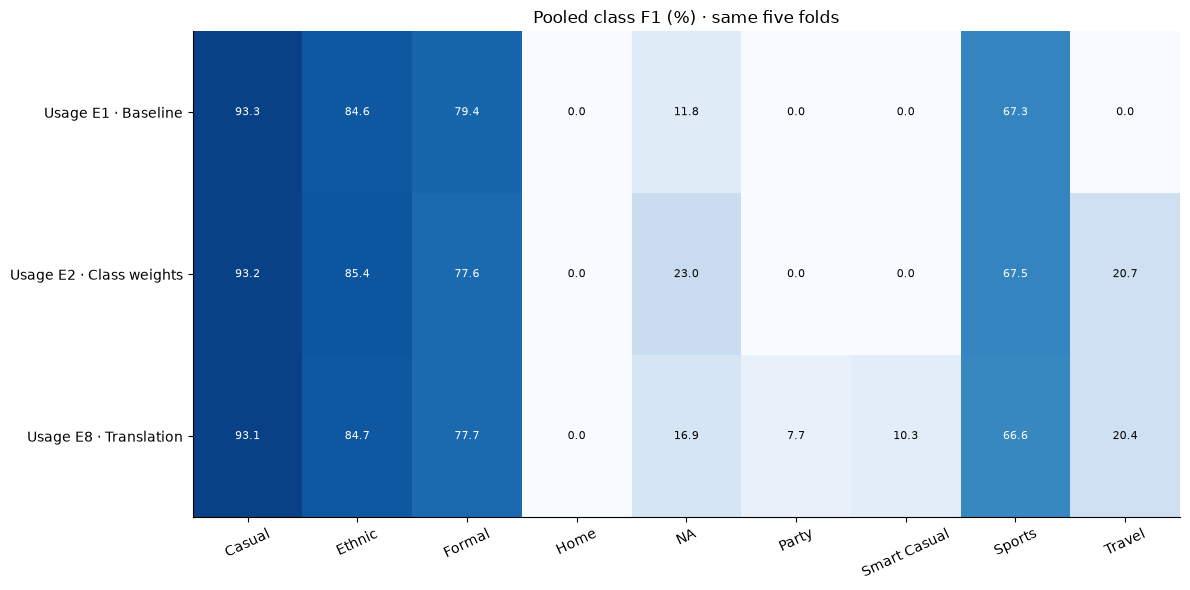

In [40]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
score_grid = class_scores.pivot(index='Stage', columns='Class', values='F1 (%)')
score_grid = score_grid.reindex([evidence_lock['stages'][key]['label'] for key in selected_stages])
fig, ax = plt.subplots(figsize=(12,6))
ax.imshow(score_grid, cmap='Blues', vmin=0, vmax=100, aspect='auto')
ax.set(xticks=range(len(score_grid.columns)), xticklabels=score_grid.columns,
       yticks=range(len(score_grid)), yticklabels=score_grid.index,
           title='Pooled class F1 (%) · same five folds')
ax.tick_params(axis='x', rotation=25)
for i,j in np.ndindex(score_grid.shape):
    value=score_grid.iloc[i,j]
    ax.text(j,i,f'{value:.1f}',ha='center',va='center',fontsize=8,
        color='white' if value>60 else 'black')
fig.tight_layout()
fig.savefig(FIGURES / "usage_all_experiments.png", dpi=150, bbox_inches="tight")
plt.show()

### Count rare detections, false alarms and the main error route

F1 alone can hide how a gain happened. The next table counts true detections and total predicted
labels on exactly the same development rows. Precision measures how often a predicted label is right;
recall measures how many real examples were found. Tiny classes need their counts beside both rates.


In [41]:
usage_count_rows, usage_matrices = [], {}
for key, name in [('usage1', 'E1'), ('usage2', 'E2'), ('usage8', 'E8')]:
    metrics = registry.loc[evidence_lock['stages'][key]['run_ids']].metrics_json.map(json.loads)
    cm = np.sum([metric['confusion_matrix'] for metric in metrics], axis=0)
    labels = [row['class_name'] for row in metrics.iloc[0]['per_class']]
    usage_matrices[name] = pd.DataFrame(cm, index=labels, columns=labels)
    for j, label in enumerate(labels):
        support, predicted, correct = int(cm[j].sum()), int(cm[:, j].sum()), int(cm[j, j])
        usage_count_rows.append([name, label, support, correct, predicted,
            100*correct/predicted if predicted else 0, 100*correct/support if support else 0])
usage_counts = pd.DataFrame(usage_count_rows, columns=[
    'Model', 'Class', 'Images', 'Correct', 'Predictions', 'Precision (%)', 'Recall (%)'])
rare_counts = usage_counts.loc[
    usage_counts.Class.isin(['Home','NA','Party','Smart Casual','Travel'])]
display(rare_counts.set_index(['Class', 'Model']).sort_index().round(2))
display(pd.DataFrame({name: matrix.loc[['Casual', 'Sports'], ['Casual', 'Sports']].stack()
    for name, matrix in usage_matrices.items()}).rename_axis(['True', 'Predicted']))


Images  Correct  Predictions  Precision (%)  Recall (%)
Class        Model                                                         
Home         E1          1        0            0           0.00        0.00
             E2          1        0            0           0.00        0.00
             E8          1        0            0           0.00        0.00
NA           E1         61        4            7          57.14        6.56
             E2         61       10           26          38.46       16.39
             E8         61       12           81          14.81       19.67
Party        E1         12        0            0           0.00        0.00
             E2         12        0            1           0.00        0.00
             E8         12        1           14           7.14        8.33
Smart Casual E1         47        0            0           0.00        0.00
             E2         47        0            5           0.00        0.00
             E8         47        6           69           8.70       12.77
Travel       E1         22        0            1           0.00        0.00
             E2         22        3            7          42.86       13.64
             E8         22        5           27          18.52       22.73

E1     E2     E8
True   Predicted                     
Casual Casual     23923  23861  23880
       Sports       712    722    574
Sports Casual      1255   1249   1363
       Sports      2070   2085   1966

**Weighting recovered some rare detections.** NA detections rise from four to ten and Travel from zero to three.
But Home, Party and Smart Casual remain at zero. E2 raises the cost of their errors without
creating enough useful examples to learn a transferable boundary. This supports retaining the
loss for supported minority classes, while rejecting the claim that weighting solves the tail.

**Translation extended coverage at a precision cost.** E8 finds 12 NA, one Party, six Smart Casual and five Travel items.
It also predicts NA 81 times, Party 14 times, Smart Casual 69 times and Travel 27 times.
Most of these rare predictions are wrong. NA recall rises, yet its precision falls enough for
F1 to decline. Sports detections fall from 2,085 to 1,966 as Sports→Casual errors rise from
1,249 to 1,363. Conversely, Casual→Sports errors fall from 722 to 574. Translation changes
the boundary in both directions; the equal-class gain is not a free improvement for every class.


**Usage E8 — translation fixes alignment sensitivity, not the class problem**

Translation improved four of five folds, pooled macro-F1 by 0.0112, macro-F1 without Home by 0.0126, NLL from 0.3428 to 0.3292, and ECE-15 from 0.0331 to 0.0079. The clean train-validation gap fell to 0.3750. Translation corruption improved by 0.0600 to only -0.0269, and wrong predictions at confidence at least 0.99 fell from 278 to 64. These tests show reduced sensitivity to shifts and fewer extremely confident errors; they do not identify the internal feature responsible.

The clean gain is not reliable across product families: the paired interval against E2 crosses zero, and the interval against E3 is -0.0239 to +0.0318. The main score misses 0.4262, and the no-Home score misses 0.4782. NA F1 fell from 0.2299 to 0.1690. The apparent rare-tail gain includes only one correct Party row and six correct Smart Casual rows. Fold 0 supplies most of the gain, fold 4 regresses, and dark-image robustness is 0.0330 worse than E2. The shift test improved, but the rare-class counts and uncertainty do not establish a stable clean-score gain or resolved label ambiguity.



**Decision.** Retain E2's demonstrated gain, and describe E8's additional trade-offs separately. E8 supplies a useful
macro-F1 benchmark and the later expansion recipe, but the small rare-class gains are unstable.
The broader comparison also tested dropout, residual/ConvNeXt networks, smoothing, focal loss
and exception balancing. The table below recomputes all nine original Usage comparisons from their saved confusion counts.
These runs do not establish a reliable rare-class solution. The next retained alternative tests fixed image
features; the later data experiment tests whether lack of examples is the stronger limit.

In [42]:
compact_rows = []
for key in ['usage1', 'usage2', 'usage3', 'usage4', 'usage5',
            'usage6', 'usage7', 'usage8', 'usage9']:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    metrics = runs.metrics_json.map(json.loads)
    cm = np.sum([row['confusion_matrix'] for row in metrics], axis=0)
    denominator = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denominator,
                   out=np.zeros(len(cm)), where=denominator > 0)
    compact_rows.append([stage['label'], ', '.join(map(str, stage['folds'])),
                         stage['labels'], int(cm.sum()),
                         100*f1.mean(), 100*np.trace(cm)/cm.sum()])
display(pd.DataFrame(compact_rows, columns=[
    'Experiment', 'Folds', 'Label basis', 'Images', 'Macro-F1 (%)', 'Accuracy (%)'
]).set_index('Experiment').round(2))


,Folds,Label basis,Images,Macro-F1 (%),Accuracy (%)
Experiment,,,,,
Usage E1 · Baseline,"0, 1, 2, 3, 4",Original,32772,37.38,89.30
Usage E2 · Class weights,"0, 1, 2, 3, 4",Original,32772,40.82,89.15
Usage E3 · Dropout 0.20,"0, 1, 2, 3, 4",Original,32772,41.61,89.17
Usage E4 · TinyResNet,"0, 1, 2, 3, 4",Original,32772,38.78,87.99
Usage E5 · Label smoothing,"0, 1, 2, 3, 4",Original,32772,40.49,89.27
Usage E6 · Focal loss,"0, 1, 2, 3, 4",Original,32772,40.94,88.82
Usage E7 · TinyConvNeXt,"0, 1, 2, 3, 4",Original,32772,34.51,85.22
Usage E8 · Translation,"0, 1, 2, 3, 4",Original,32772,41.94,88.85
Usage E9 · Exception balance,"0, 1, 2, 3, 4",Original,32772,39.55,83.70


**The other recipes did not establish a replacement.** E3 adds dropout [11] to reduce
memorisation. Its 41.61% pooled F1 is close to E8's 41.94%, so the difference is not enough
to claim a reliable advantage without the paired comparison. E4 tests residual connections [5],
while E7 adapts ConvNeXt's large depthwise kernels and block design [16]; their 38.78% and 34.51% F1 do not support more capacity as
the answer under these budgets. E5 smooths targets to reduce extreme confidence, but reaches
40.49%. E6 uses focal modulation [17] to focus loss on hard cases and reaches 40.94%; a difficult example is not necessarily
a visually learnable rare example. E9 changes exception balancing and reaches 39.55%. Group-robust research [18] motivates
attention to weak ArticleType–Usage groups, but this balancing rule is not Group DRO.
Label smoothing has a methodological basis in [19]; its local epsilon 0.05 trial tests
confidence control, without assuming that softer targets resolve ambiguous occasions.

These are results of specific recipes, not verdicts on whole model families. Different weighting,
augmentation and architectures interact. E8 remains the original macro-F1 benchmark, while E1
remains the accuracy alternative. The next check returns to the shift sensitivity that motivated translation and measures
its improvement alongside the lighting cost.

### Test the intended robustness gain and its cost

For E2 and E8, average each saved fold's corrupted-minus-clean macro-F1. Negative values mean
damage. This is a mean fold change, not pooled F1 or a result on final-refit weights.


Model,E2,E8
corruption,,
brightness_085,-12.89,-16.19
brightness_115,-3.16,-4.22
grayscale,-1.45,-2.08
jpeg_75,-0.07,-0.19
translation_003,-8.69,-2.69


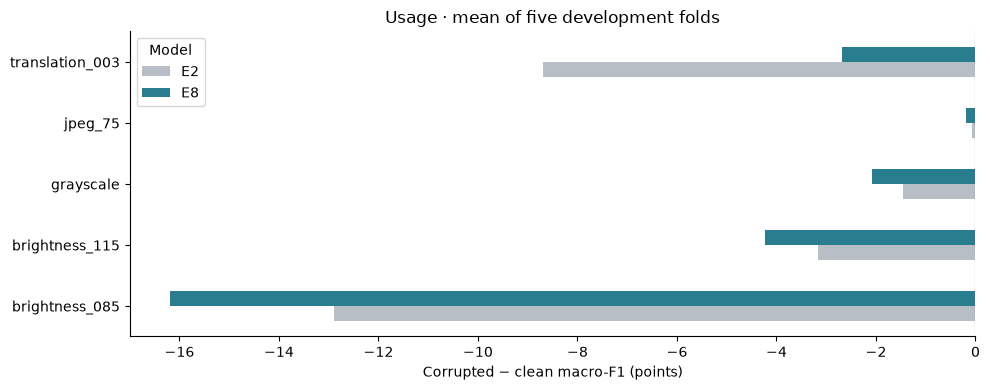

In [43]:
usage_robustness_parts = []
for key, name in [('usage2', 'E2'), ('usage8', 'E8')]:
    for relative in evidence_lock['stages'][key]['robustness_paths']:
        rows = pd.read_csv(REPO_DIR/relative, keep_default_na=False)
        rows['Model'] = name
        usage_robustness_parts.append(rows)
usage_robustness = pd.concat(usage_robustness_parts, ignore_index=True)
usage_robustness_means = usage_robustness.pivot_table(
    index='corruption', columns='Model', values='macro_f1_change', aggfunc='mean')*100
display(usage_robustness_means.round(2))
fig, ax = plt.subplots(figsize=(10, 4))
usage_robustness_means.plot.barh(ax=ax, color=['#b8bec6', '#287d8e'])
ax.axvline(0, color='#555555', linewidth=0.8)
ax.set(xlabel='Corrupted − clean macro-F1 (points)', ylabel='',
       title='Usage · mean of five development folds')
fig.tight_layout()
fig.savefig(FIGURES/'usage_robustness_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation and next step.** The translation loss shrinks by about six F1 points, but
darkening costs about 3.3 points more than E2. The intended position-tolerance gain is visible;
it does not establish general robustness. The worse dark-image result and uncertainty around the clean-score gain remain
limitations. The later E8 selection must be justified alongside these measured costs.
Because class coverage remains weak, the next branch tests a different representation with
HOG-SVM, then tests additional rare-class data. Neither hypothesis follows from accuracy alone.


### Test a classical alternative on the same two folds

Full-RGB HOG plus a linear SVM tests whether fixed edge features are more useful than the CNN
for rare occasions. Calibration turns SVM scores into probabilities and is fitted only within the
saved training folds. Scarce positive examples can make that probability fit unstable. Compare
folds 0 and 4 only; a balanced probe is a different population.

Guo et al. [20] distinguish reliable probabilities from classification accuracy. That distinction
is relevant here, although their temperature-scaling method is not the SVM sigmoid calibration
used in this screen. The saved raw-margin and calibrated results below test the local effect.


In [44]:
selected_stages = ['usage204', 'hog_u']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Usage E2 · Class weights,usage,"[0, 4]",Original,13110,40.73,89.06
Usage U2 · HOG SVM,usage,"[0, 4]",Original,13110,36.29,86.57


**U2 hypothesis and failure.** Full-RGB HOG plus a linear SVM tests the promising fixed-feature probe on a full, naturally imbalanced population. The saved calibrated model scores 36.29% F1 against E2's matched 40.73%. The paired change is −4.44 points, with a family-bootstrap interval from −6.89 to −2.44 points; both admission routes fail. All solvers converged, so an unfinished optimiser is not the explanation.

Raw SVM margins would score 40.59%, but the saved calibrated probabilities score 36.29%. Two of eight Party calibration sigmoids have reversed slopes, each based on only two or three positives from one or two families. This directly shows that the fitted calibration step damaged the saved decisions. The raw-margin readout still predicts no Party or Smart Casual and is a diagnostic, not a replacement accepted model. Base SVM train/inner-validation gaps remain about 46–47 points; the smaller ensemble training gap masks different exposures to fitting and calibration.

The earlier balanced probe also used a different estimator and population. Its stronger score is not a contradiction and cannot isolate one cause. Scarce calibration examples, representation differences and fewer base-fitting folds all matter.



**Decision and next hypothesis.** The saved calibrated SVM is rejected. Transformer, type-cascade
and two-stage screens did not establish a replacement in the retained progression; the compact screen table below shows the saved transformer and type-cascade results.
The two-stage screen is not used to choose the final recipe. They did not justify a new final model. Since changing the learner has not
recovered the rare occasions, the next test adds independent rare-class examples. This directly
tests a data limitation, while teacher-only scoring checks whether the new-source gains transfer.

In [45]:
compact_rows = []
for key in ['usage104', 'usage204', 'u1', 'swin_u', 'type_u', 'hog_u']:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    metrics = runs.metrics_json.map(json.loads)
    cm = np.sum([row['confusion_matrix'] for row in metrics], axis=0)
    denominator = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denominator,
                   out=np.zeros(len(cm)), where=denominator > 0)
    compact_rows.append([stage['label'], ', '.join(map(str, stage['folds'])),
                         stage['labels'], int(cm.sum()),
                         100*f1.mean(), 100*np.trace(cm)/cm.sum()])
display(pd.DataFrame(compact_rows, columns=[
    'Experiment', 'Folds', 'Label basis', 'Images', 'Macro-F1 (%)', 'Accuracy (%)'
]).set_index('Experiment').round(2))


,Folds,Label basis,Images,Macro-F1 (%),Accuracy (%)
Experiment,,,,,
Usage E1 · Baseline,"0, 4",Original,13110,38.43,89.07
Usage E2 · Class weights,"0, 4",Original,13110,40.73,89.06
U1 · Component weights,"0, 4",Original,13110,41.38,88.99
Usage · Scratch Micro-Swin,"0, 4",Original,13110,39.73,87.56
Usage S1 · Type cascade,"0, 4",Original,13110,31.93,85.86
Usage U2 · HOG SVM,"0, 4",Original,13110,36.29,86.57


### Audit the admitted rare-Usage additions

Version,teacher_plus_rare_usage_20260906,teacher_plus_rare_usage_v2_20260906
Usage,,
Home,16,136
Party,97,224
Smart Casual,6,162
Travel,1,165


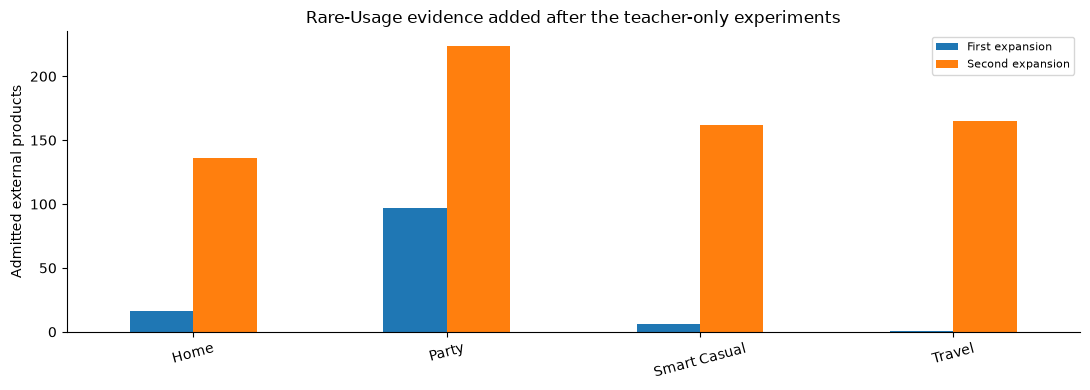

In [46]:
expanded_paths = ['data/processed/teacher_plus_rare_usage_20260906/splits.csv',
                  'data/processed/teacher_plus_rare_usage_v2_20260906/splits.csv']
intake_rows=[]
teacher_ids=set(splits.id.astype(str))
for path in expanded_paths:
    expanded=pd.read_csv(REPO_DIR/path,keep_default_na=False,low_memory=False)
    external=expanded.loc[~expanded.id.astype(str).isin(teacher_ids)]
    for label,count in external.usage.value_counts().items():
        intake_rows.append([Path(path).parent.name,label,count])
intake=pd.DataFrame(intake_rows,columns=['Version','Usage','Added products'])
display(intake.pivot(index='Usage',columns='Version',values='Added products').fillna(0).astype(int))
fig,ax=plt.subplots(figsize=(11,4))
intake.pivot(index='Usage',columns='Version',values='Added products').fillna(0).plot.bar(
    ax=ax,rot=15)
ax.set(ylabel='Admitted external products',xlabel='',
    title='Rare-Usage evidence added after the teacher-only experiments')
ax.legend(['First expansion','Second expansion'],fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "usage_expansion_intake.png", dpi=150, bbox_inches="tight")
plt.show()

**The remaining failures motivated additional data.** More independent families can give a small class more examples to learn from. Yet outside retail photos may have different products, backgrounds or label meanings. The fair test is performance on the same teacher rows. A better score on a mixture of teacher and outside images does not establish that benefit. Literal `NA` remains a class; the one blank target remains excluded.

## 17. Usage: the effect of adding rare-class images

Weighting, translation and alternative learners had left the rare occasions poorly recognised.
The next intervention therefore changed the available examples: additional rare-class families
were introduced while retaining the teacher folds and E8 recipe. Success was judged on the
same teacher images, because a gain on the new retail source alone would not solve the
original task.

The tables read pinned, completed evidence. Original model scores come from registered fold
confusion counts. Expanded runs use their saved teacher-only prediction audits because their
registry totals also include outside images.


### Verify the saved evidence and compare the same five teacher folds

In [47]:
usage_lock = json.loads((USAGE_HISTORY/'evidence_lock.json').read_text())
usage_files = usage_lock['sources']
for relative, expected in usage_lock['files'].items():
    saved = REPO_DIR / relative.replace('reports/task3_', 'reports/task3/', 1)
    assert hashlib.sha256(saved.read_bytes()).hexdigest() == expected, relative
usage120 = json.loads((REPO_DIR/usage_files['expanded120_confusions']).read_text())
usage687 = json.loads((REPO_DIR/usage_files['expanded687_summary']).read_text())
usage_dev_rows = []
for label, key in [('E1', 'usage1'), ('E8', 'usage8')]:
    rows = registry.loc[evidence_lock['stages'][key]['run_ids']]
    assert rows.status.eq('complete').all() and sorted(rows.validation_fold) == list(range(5))
    matrices = [json.loads(value)['confusion_matrix'] for value in rows.metrics_json]
    matrix = np.sum(matrices, axis=0)
    denominator = matrix.sum(axis=0) + matrix.sum(axis=1)
    f1 = np.divide(2*matrix.diagonal(), denominator,
                   out=np.zeros(9), where=denominator>0).mean()
    usage_dev_rows.append([label, int(matrix.sum()), np.trace(matrix)/matrix.sum(), f1])
for label, result in [('E8 +120', usage120['teacher']),
                      ('E8 +687', usage687['sources']['teacher']['metrics'])]:
    matrix = np.asarray(result['confusion_matrix'])
    usage_dev_rows.append([label, int(matrix.sum()), result['accuracy'], result['macro_f1']])
usage_development_scores = pd.DataFrame(usage_dev_rows,
    columns=['Model','Images','Accuracy','Macro-F1']).set_index('Model')
assert usage_development_scores.Images.eq(32772).all()
display(usage_development_scores.round(6))

,Images,Accuracy,Macro-F1
Model,,,
E1,32772,0.892988,0.373756
E8,32772,0.888533,0.419393
E8 +120,32772,0.887495,0.408634
E8 +687,32772,0.895093,0.409277


**Result.** E1 scores 89.30% accuracy and 0.373756 macro-F1. E8 scores 88.85% and 0.419393. Adding 120 images lowers teacher macro-F1 to 0.408634; adding 687 gives 0.409277. The larger set raises teacher accuracy to 89.51%, so E1 is not the accuracy winner of this expanded development comparison.

The 687-image change against original E8 has a family-resampling 95% interval of −0.0348 to +0.0144 F1. It includes zero. There is no demonstrated gain; the observed decrease is not proof that adding data always hurts. One seed and repeated use of these folds limit the claim.

### Locate the effect of extra data on teacher classes

Keep the evaluation population fixed: original teacher development images, predicted out of fold.
The table below recomputes each class F1 from teacher-only confusion matrices. Extra-source
validation rows are excluded from these scores. This avoids mistaking success on retailer photos
for success on the original task.


In [48]:
expanded_class_scores = {}
for name, matrix in [('E8', usage_matrices['E8'].to_numpy()),
    ('E8 +120', np.asarray(usage120['teacher']['confusion_matrix'])),
    ('E8 +687', np.asarray(usage687['sources']['teacher']['metrics']['confusion_matrix']))]:
    denominator = matrix.sum(axis=0)+matrix.sum(axis=1)
    expanded_class_scores[name] = np.divide(2*matrix.diagonal(), denominator,
        out=np.zeros(len(matrix)), where=denominator > 0)*100
expanded_class_view = pd.DataFrame(expanded_class_scores, index=usage_matrices['E8'].index)
expanded_class_view['+120 change (points)'] = expanded_class_view['E8 +120']-expanded_class_view.E8
expanded_class_view['+687 change (points)'] = expanded_class_view['E8 +687']-expanded_class_view.E8
display(expanded_class_view.round(2))


,E8,E8 +120,E8 +687,+120 change (points),+687 change (points)
Casual,93.05,92.97,93.39,-0.08,0.34
Ethnic,84.74,85.02,86.24,0.28,1.50
Formal,77.71,76.98,79.91,-0.73,2.21
Home,0.00,0.00,0.00,0.00,0.00
NA,16.90,22.22,23.62,5.32,6.72
Party,7.69,0.00,0.00,-7.69,-7.69
Smart Casual,10.34,3.85,0.00,-6.50,-10.34
Sports,66.61,66.33,69.05,-0.28,2.44
Travel,20.41,20.41,16.13,0.00,-4.28


**The class breakdown explains the aggregate result.** With 687 additions, NA gains 6.72 F1 points, Sports
gains 2.44 and Formal gains 2.21. But Party loses 7.69, Smart Casual loses 10.34 and Travel
loses 4.28. Party and Smart Casual reach zero despite being targets of the collection effort.
The 120-image trial already shows that tension: NA improves while Party and Smart Casual fall.
The common-class gains help accuracy, but they do not establish the intended rare-class benefit.

**The comparison isolates the added-data package.** The +120 and +687 runs retain the E8 recipe, so they
test added training evidence more directly than changing both learner and data. More images
still change source mix and family support. The aggregate teacher F1 fails to improve, so this
branch has not met its purpose even if accuracy increases. The following source comparison
tests a possible reason: whether the rare labels were learned mainly from the new photo source.
It can expose a transfer failure, but cannot isolate background, product type or label meaning
as its cause without an additional controlled test.


### Check whether learning transfers between sources

cohort,Newest 567 images,Teacher
class_name,,
Home,116 / 120,0 / 1
Party,125 / 127,0 / 12
Smart Casual,147 / 156,0 / 47
Travel,137 / 164,5 / 22


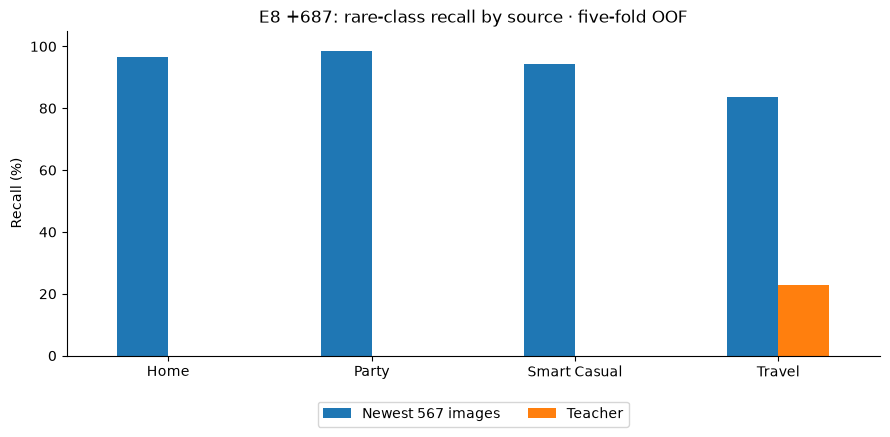

In [49]:
source_scores = pd.read_csv(REPO_DIR/usage_files['source_classes'], keep_default_na=False)
rare_names = ['Home','Party','Smart Casual','Travel']
source_view = source_scores.loc[source_scores.class_name.isin(rare_names) &
    source_scores.cohort.isin(['teacher','new_added'])].copy()
source_view['Correct / images'] = (source_view.correct.astype(str) +
                                  ' / ' + source_view.support.astype(str))
source_labels = {'teacher':'Teacher','new_added':'Newest 567 images'}
display(source_view.pivot(index='class_name', columns='cohort',
    values='Correct / images').reindex(rare_names).rename(columns=source_labels))
fig, ax = plt.subplots(figsize=(9,4.5))
source_view.pivot(index='class_name', columns='cohort', values='recall').reindex(
    rare_names).rename(columns=source_labels).mul(100).plot.bar(ax=ax, rot=0)
ax.set(xlabel='', ylabel='Recall (%)', ylim=(0,105),
       title='E8 +687: rare-class recall by source · five-fold OOF')
ax.legend(title='', loc='upper center', bbox_to_anchor=(.5,-.12), ncol=2)
fig.tight_layout()
fig.savefig(FIGURES/'usage_source_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding.** The 687-image model detects 125/127 new-source Party and 147/156 new-source Smart Casual images. On the teacher rows, it detects 0/12 Party and 0/47 Smart Casual. It learns the outside examples, but that success does not carry to these teacher classes. The earlier 120-image model also missed all teacher Party cases.

The mixed-source F1 of 0.7567 measures a changed class and source mix. It cannot replace the teacher-only score of 0.4093. Coverage was uneven: the teacher Smart Casual class contains 18 watches, while the 162 added Smart Casual images contain none. Product types also overlap: a dress can be Casual or Party. These are useful clues, not proof of wrong labels or a faulty architecture.

The next experiments followed these two observations separately in intent: reduce the
expanded model's exact fit, then improve the types of outside products represented. Their
teacher-only results, rather than the new-source scores, determined whether either helped.


## 18. Usage: follow-up failures and the fixed refits

The expansion revealed a gap between strong recognition on the added source and continued
failure on teacher rare classes. Two follow-ups examined that gap. The first combined MixUp
and SAM to reduce exact fitting; the second replaced 130 outside images to address coverage
differences. Their results determined whether the expanded-data path should continue before
the final teacher-only refits were completed.


### Separate the two follow-up hypotheses

**V2 MixUp + SAM:** the expanded model fits outside examples much better than teacher rare
examples. MixUp [13] changes the training examples and SAM [14] changes the weight update.
Together they test whether a less exact fit improves transfer; success in Gender does not
establish success for Usage's different labels and added image sources. Both methods change together, so this is a combined-recipe test. A smaller training gap
counts as progress only if teacher validation holds up; underfitting can also shrink a gap.

**V3 replacements:** after that failure, 130 outside images are replaced with reviewed products
intended to better match the missing teacher categories. Class totals and all teacher rows stay
fixed, along with retained outside rows and folds. This tests the replacement package, not simply
the number of images. Score it against V2 on the same folds 0 and 4. The table and paired error
counts below determine whether the more suitable examples actually transfer.


In [50]:
usage_mix = json.loads((REPO_DIR/usage_files['mixup_summary']).read_text())
usage_v3 = json.loads((REPO_DIR/usage_files['v3_summary']).read_text())
assert usage_mix['folds'] == usage_v3['folds'] == [0,4]
assert usage_mix['teacher_rows'] == usage_v3['teacher_rows'] == 13110
screen = pd.DataFrame([
    ['E8 +687', usage_mix['baseline_teacher_f1']],
    ['v2 MixUp + SAM', usage_mix['candidate_teacher_f1']],
    ['v3 MixUp + SAM', usage_v3['candidate_teacher_f1']]],
    columns=['Model','Teacher macro-F1'])
display(screen.set_index('Model').round(6))
fit_rows = pd.DataFrame(usage_mix['mean_teacher_fit']).T.rename(
    index={'mixup_sam':'v2 MixUp + SAM','v2_e8':'E8 +687'})
fit_rows.loc['v3 MixUp + SAM'] = pd.Series(usage_v3['mean_teacher_fit']['v3'])
fit_rows = fit_rows.reindex(screen.Model)
fit_labels = {'teacher_train_f1':'Clean train F1',
              'teacher_validation_f1':'Validation F1','teacher_gap':'Gap'}
display(fit_rows.rename(columns=fit_labels).round(4))

,Teacher macro-F1
Model,
E8 +687,0.400984
v2 MixUp + SAM,0.389790
v3 MixUp + SAM,0.377773


,Gap,Clean train F1,Validation F1
Model,,,
E8 +687,0.4173,0.8182,0.4010
v2 MixUp + SAM,0.2157,0.6049,0.3892
v3 MixUp + SAM,0.2158,0.5938,0.3780


**Result.** On the same 13,110 teacher images, E8 +687 scores 0.400984, v2 MixUp + SAM scores 0.389790, and v3 scores 0.377773. These are two-fold scores; they must not be ranked against the five-fold table in Section 17.

The v2 gap falls from 0.4173 to 0.2157 mainly because training F1 falls. Validation F1 falls too. V3 leaves the gap almost unchanged at 0.2158. It fixes 208 teacher errors but adds 242. Its paired family interval against v2 is −0.0263 to −0.0012 F1, supporting a decrease for these saved predictions. It does not measure variation across training seeds.

**Failure and decision.** Both trials miss all six teacher Party and all 18 Smart Casual cases on these folds. V3 also loses the one Travel case v2 detected. It gets only 27/76 replacement validation photos right despite fitting many replacement training photos. More suitable product types alone were insufficient under this recipe. Keep both completed trials as evidence; neither is the final model. MixUp and SAM changed together, so their separate effects are unknown.

**The accumulated evidence ended this branch.** The new-source recall gains did not transfer to teacher Party and
Smart Casual. Regularisation reduced training fit without improving teacher validation; more suitable
replacement product types were also insufficient under this recipe.

E1 still has a large training–validation difference. Its development corruption checks lose a mean
6.68 F1 points under darkening and 6.42 under translation. Expanded models also retain large clean
gaps. Their corruption audits include outside images, so they cannot prove a matched teacher-only
robustness gain. A smaller gap alone is not a selection reason. The v2/v3 fit gaps are displayed above. The historical original-fit table below labels
online training scores separately from clean checkpoint scores; they are not interchangeable.

In [51]:
historical_fit = pd.read_csv(
    REPO_DIR/'reports/task3/usage_deep_investigation_20260905/fit_summary.csv',
    keep_default_na=False)
fit_view = historical_fit[['model', 'train_source', 'macro_f1', 'train_macro_f1', 'gap']].copy()
fit_view[['macro_f1', 'train_macro_f1', 'gap']] *= 100
display(fit_view.rename(columns={'model':'Model', 'train_source':'Training score basis',
    'macro_f1':'Validation F1 (%)', 'train_macro_f1':'Training F1 (%)',
    'gap':'Gap (points)'}).set_index('Model').round(2))


,Training score basis,Validation F1 (%),Training F1 (%),Gap (points)
Model,,,,
E1,last online epoch,37.41,65.46,28.05
E2,last online epoch,40.43,93.85,53.42
E3,clean final checkpoint,41.40,92.91,51.51
E4,clean final checkpoint,38.58,97.62,59.04
E5,clean final checkpoint,40.33,94.20,53.87
E6,clean final checkpoint,40.56,93.73,53.17
E7,clean final checkpoint,34.74,68.38,33.64
E8,clean final checkpoint,41.55,79.05,37.50
E9,clean final checkpoint,39.47,77.75,38.28


### Refit the fixed Usage recipes on all development images

A refit trains a fresh model using all eligible development rows after the recipe is set.
Both E1 and E8 completed **30 fixed epochs on 32,772 teacher images**. One blank Usage target
is masked; literal `NA` remains a class. They use the same canonical split, class order,
391,209-parameter SmallCNN and seed 2753. No external additions enter these refits.

E1 uses ordinary cross-entropy and no augmentation. E8 uses effective-number weighted
cross-entropy and a translation of up to two pixels with probability 0.5. Both refit their
normalization on full-development content pixels, excluding padding. E8 also recalculates
its class weights from those same rows. Neither run uses validation or early stopping.

#### Completed registered runs

The table comes from the two completed `results/runs.csv` records, preserved in a checked
snapshot. It records training completion and cost, not performance on unseen images.


In [52]:
from fashion.task3_final import verify_usage_final

usage_final_manifest = verify_usage_final(REPO_DIR)
refit_runs = pd.read_csv(USAGE_FINAL/'refit_runs.csv', keep_default_na=False)
assert len(refit_runs) == 2 and refit_runs.status.eq('complete').all()
refit_metrics = refit_runs.metrics_json.map(json.loads)
refit_training = pd.DataFrame({
    'Model': ['E1 refit', 'E8 refit'],
    'Images': refit_runs.training_product_count.astype(int),
    'Epochs': refit_metrics.map(lambda row: row['epochs_completed']),
    'Validation images': refit_runs.validation_product_count.astype(int),
    'Train minutes': refit_runs.train_seconds.astype(float)/60,
    'Parameters': refit_runs.parameter_count.astype(int),
    'Checkpoint bytes': refit_runs.checkpoint_bytes.astype(int)})
pd.testing.assert_frame_equal(refit_training,
    pd.read_csv(USAGE_FINAL/'refit_training_summary.csv', keep_default_na=False))
display(refit_training.set_index('Model').round({'Train minutes': 2}))

,Images,Epochs,Validation images,Train minutes,Parameters,Checkpoint bytes
Model,,,,,,
E1 refit,32772,30,0,8.32,391209,1581813
E8 refit,32772,30,0,8.81,391209,1584821


#### Training behaviour

The loss curves use separate panels because E1's unweighted loss and E8's weighted loss have
different definitions. A lower loss across these panels does not identify the better model.


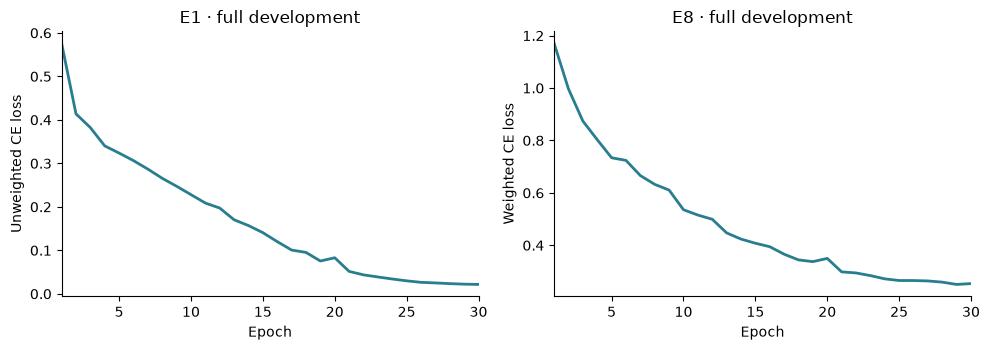

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, name, loss in zip(axes, ['E1', 'E8'], ['Unweighted CE', 'Weighted CE']):
    folder = TASK3_EVIDENCE_ROOT/f'usage_{name.lower()}_refit_20260907'
    history = pd.read_csv(folder/'history.csv', keep_default_na=False)
    assert history.epoch.tolist() == list(range(1, 31))
    assert history.training_rows.eq(32772).all()
    ax.plot(history.epoch, history.train_loss, color='#287d8e', linewidth=2)
    ax.set(xlabel='Epoch', ylabel=f'{loss} loss', title=f'{name} · full development',
           xlim=(1, 30))
fig.tight_layout()
fig.savefig(FIGURES/'usage_refit_training.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding.** E1's training loss falls from 0.5759 to 0.0216; E8's falls from 1.1703 to 0.2540.
Both fits complete their planned budget. E8 takes 8.81 minutes on an NVIDIA L4, compared with
E1's 8.32 minutes. These are recorded runs, not repeated hardware benchmarks.

There is no validation curve for either refit. Their earlier five-fold OOF scores belong to the
fold models; those scores cannot be assigned to these new checkpoints. Predicting development
rows with the refit would measure training exposure, not independent validation. Training loss
alone cannot show whether the known generalization gap or rare-class failures have improved.


### Retained E8 recipe and evaluation handoff

**Final Usage model: the single teacher-only E8 refit, epoch 30.**
The tested gain in class-level performance justifies the smaller loss in overall accuracy
for this nine-class task. Macro-F1 gives every class equal weight, which exposes failures
that accuracy can hide when Casual dominates the data.
In the original five-fold development comparison, E8 reaches **41.94% macro-F1** versus
E1's **37.38%**, with accuracy **88.85% versus 89.30%**. We accept that measured 0.45-point accuracy loss for the 4.56-point macro-F1 gain;
E1 remains better at total correct predictions, but E8 has the stronger class-level result.
The rare-data expansion and later regularisation trials did not establish a stronger teacher
macro-F1 alternative. These development findings explain the recipe choice; the completed
reserved-holdout comparison and final evaluation judgement are in the Task 3 evaluation notebook (`04_task3_final_evaluation.ipynb`).

The accepted artifact is newly trained from scratch on full development, using the fixed E8
recipe. It is one checkpoint, not the old five-model average. The owner accepted it on 7 September 2026 after evaluation review.

The final choice is a later acceptance based on the completed comparisons. It does not
turn E8's earlier failed score, uncertainty and dark-image checks into passes. E8's observed
lead over E2 and E3 is not an established statistically reliable lead; retaining it uses its
measured nine-class score, probability checks and shift-test benefit while accepting the
recorded darkening cost. The final refit judgement belongs to the evaluation notebook.

#### Frozen prediction recipe

Use RGB at height 80 and width 60, EXIF orientation, aspect-preserving LANCZOS resize and
centred letterboxing. Apply the refit's saved full-development RGB mean and standard deviation,
with padding zeroed after normalization. Run this model in evaluation mode, apply softmax,
then choose the class with the largest probability. Keep all nine labels, including literal `NA`.
Translation and class weights apply during training only. Do not adjust prediction probabilities.

The model uses channels 32/64/128/256 and global average pooling, with no classifier dropout.
The fixed fit uses AdamW at 0.001, weight decay 0.0001, batch 128 and cosine decay over 30 epochs
to 0.00001. E8's class-weight settings are beta 0.999 and cap 5. Epoch 30 is final, not a best epoch.
The manifest pins the exact weights, class order, configuration, normalization and source hashes.


In [54]:
print('Final run:', usage_final_manifest['run_id'])
print('Checkpoint:', usage_final_manifest['checkpoint']['path'])
print('SHA-256:', usage_final_manifest['checkpoint']['sha256'])
print('Class order:', ', '.join(usage_final_manifest['class_names']))
print('Artifact: one scratch SmallCNN; epoch 30; 391,209 parameters')
usage_normalization = json.loads(
    (REPO_DIR/usage_final_manifest['normalization']['path']).read_text())
display(pd.DataFrame({'Channel': ['R', 'G', 'B'],
    'Mean': usage_normalization['mean'],
    'Standard deviation': usage_normalization['std']
}).set_index('Channel').round(6))


Final run: t3_usage_e8_translation_teacher_all_development_refit_5553be0c138243e9
Checkpoint: results/evidence/task3/usage_e8_refit_20260907/final_epoch.pt
SHA-256: 18da75a4ec935ab0d18c9ebdf9d1dabb6fa87ee484ead5f439de0192c4af2747
Class order: Casual, Ethnic, Formal, Home, NA, Party, Smart Casual, Sports, Travel
Artifact: one scratch SmallCNN; epoch 30; 391,209 parameters


,Mean,Standard deviation
Channel,,
R,0.849998,0.271110
G,0.833253,0.282661
B,0.827605,0.286203


**Limits and handoff.** Small and overlapping occasion classes still need careful review.
The development study uses one seed and repeated fold comparisons; it cannot prove a stable
ranking across future runs or new catalogues. A single refit reduces the number of forward passes,
but an application speedup has not been measured. The frozen model supports catalogue-tag
suggestions; the evidence does not establish reliable automatic tagging of every Usage class.

The code above displays the accepted checkpoint, class order and saved normalization.
The training records and curves are reproduced in this section.
Reserved-holdout results and analysis remain in the Task 3 evaluation notebook (`04_task3_final_evaluation.ipynb`).
The teacher did not supply test labels: the official deliverable is predictions in the fixed
`id,gender,articleType,season,usage` format. This notebook does not score that set.


## 19. Development findings and limits

**Gender.** Pooling improves the baseline's class separation, but near-perfect training fit persists.
Translation, dropout, darkening and grayscale address specific weaknesses with mixed clean-score
and robustness effects. The label audit changes the scoring basis, so that jump cannot be counted
as a model-only improvement. On matched corrected-label screens, MixUp reaches 80.89% F1;
SAM25 scores 79.86% on the same screen, reduces the gap from 12.91 to 9.93 points,
retains 361 Unisex detections and improves F1 over SAM30's 79.43%. These results justified advancing
the recipe despite its 1.03-point F1 loss; the smaller gap was not the only reason. Its fixed five-fold
audit reaches 79.73% F1 with a 10.15-point mean gap. Those are development results, not a claim
that SAM25 outperforms every candidate on unseen data. The accepted final artifact is now the
single full-development SAM25 refit, recorded after the fold study in Section 15. Its training
completion does not create a new OOF score; its holdout analysis is in the Task 3 evaluation notebook (`04_task3_final_evaluation.ipynb`).

**Usage.** Class weighting improves supported minority classes; translation improves position
tolerance but leaves unstable rare-class gains and a darkening cost. E1 has the highest accuracy
among the original nine teacher-only experiments; E8 leads their macro-F1 comparison. On the
same teacher development rows, the 687-image expansion raises accuracy above E1, yet fails to
improve E8's macro-F1. Its strong outside-source recall does not carry to teacher Party and Smart
Casual. Later regularisation and photo replacements lower teacher validation F1. These results
show why neither extra complexity nor a smaller training gap is enough to establish progress.
The completed E1 and E8 refits use all eligible development rows. Their loss curves show training
completion, not new validation evidence; the E8 recipe is retained because its matched development F1 is 4.56 points above
E1 for a 0.45-point accuracy loss, with additional rare-class detections. This is the
measured trade-off accepted for the nine-label task; the refit test is reported separately.

**Remaining uncertainty.** Most comparisons use one seed and repeatedly consulted development
folds. Family resampling measures uncertainty within saved predictions, not variation across seeds
or the full cost of trying many recipes. Two-fold screens cannot be ranked against five-fold totals;
changed labels and source mixtures also require separate comparisons. Ambiguous images,
rare support and catalogue-specific cues remain competing explanations for the errors.


Section 18 records the completed Usage refits and the accepted E8 recipe.
Reserved-holdout scores and final evaluation analysis stay in the Task 3 evaluation notebook (`04_task3_final_evaluation.ipynb`).
The official test set is for predictions only. Development findings above retain their original basis.

The development study therefore hands two fixed models to final evaluation with different
claims to test: a simpler Gender refit following the label and regularisation study, and a
Usage refit whose broader class coverage must be weighed against common-class errors. The
evaluation notebook follows those claims through the saved holdout results and practical costs.


## 20. References


[1] Y. Bengio and Y. Grandvalet, “No Unbiased Estimator of the Variance of K-Fold Cross-Validation,” *Journal of Machine Learning Research*, vol. 5, pp. 1089–1105, 2004.

[2] N. Dalal and B. Triggs, “Histograms of Oriented Gradients for Human Detection,” in *CVPR*, 2005. doi: 10.1109/CVPR.2005.177.

[3] D. Hendrycks and T. Dietterich, “Benchmarking Neural Network Robustness to Common Corruptions and Perturbations,” in *ICLR*, 2019. arXiv:1903.12261.

[4] F. Radenović, G. Tolias, and O. Chum, “Fine-Tuning CNN Image Retrieval with No Human Annotation,” *IEEE Transactions on Pattern Analysis and Machine Intelligence*, vol. 41, no. 7, pp. 1655–1668, 2019. doi: 10.1109/TPAMI.2018.2846566.

[5] K. He, X. Zhang, S. Ren, and J. Sun, “Deep Residual Learning for Image Recognition,” in *CVPR*, 2016. arXiv:1512.03385.

[6] R. Zhang, “Making Convolutional Networks Shift-Invariant Again,” in *ICML*, PMLR, vol. 97, pp. 7324–7334, 2019.

[7] K. Sun, B. Xiao, D. Liu, and J. Wang, “Deep High-Resolution Representation Learning for Human Pose Estimation,” in *CVPR*, 2019. arXiv:1902.09212.

[8] R. Caruana, “Multitask Learning,” *Machine Learning*, vol. 28, pp. 41–75, 1997. doi: 10.1023/A:1007379606734.

[9] T. Standley et al., “Which Tasks Should Be Learned Together in Multi-task Learning?,” in *ICML*, PMLR, vol. 119, pp. 9120–9132, 2020.

[10] I. Loshchilov and F. Hutter, “Decoupled Weight Decay Regularization,” in *ICLR*, 2019. arXiv:1711.05101.

[11] N. Srivastava et al., “Dropout: A Simple Way to Prevent Neural Networks from Overfitting,” *Journal of Machine Learning Research*, vol. 15, pp. 1929–1958, 2014.

[12] C. G. Northcutt, L. Jiang, and I. L. Chuang, “Confident Learning: Estimating Uncertainty in Dataset Labels,” *Journal of Artificial Intelligence Research*, vol. 70, pp. 1373–1411, 2021. doi: 10.1613/jair.1.12125.

[13] H. Zhang, M. Cisse, Y. N. Dauphin, and D. Lopez-Paz, “mixup: Beyond Empirical Risk Minimization,” in *ICLR*, 2018. arXiv:1710.09412.

[14] P. Foret, A. Kleiner, H. Mobahi, and B. Neyshabur, “Sharpness-Aware Minimization for Efficiently Improving Generalization,” in *ICLR*, 2021. arXiv:2010.01412.

[15] Y. Cui, M. Jia, T.-Y. Lin, Y. Song, and S. Belongie, “Class-Balanced Loss Based on Effective Number of Samples,” in *CVPR*, 2019. arXiv:1901.05555.

[16] Z. Liu et al., “A ConvNet for the 2020s,” in *CVPR*, 2022. arXiv:2201.03545.

[17] T.-Y. Lin et al., “Focal Loss for Dense Object Detection,” in *ICCV*, 2017. arXiv:1708.02002.

[18] S. Sagawa, P. W. Koh, T. B. Hashimoto, and P. Liang, “Distributionally Robust Neural Networks for Group Shifts: On the Importance of Regularization for Worst-Case Generalization,” in *ICLR*, 2020. arXiv:1911.08731.

[19] C. Szegedy et al., “Rethinking the Inception Architecture for Computer Vision,” in *CVPR*, 2016. arXiv:1512.00567.

[20] C. Guo, G. Pleiss, Y. Sun, and K. Q. Weinberger, “On Calibration of Modern Neural Networks,” in *ICML*, PMLR, vol. 70, pp. 1321–1330, 2017.
